In [1]:
RUN_C4_EXPERIMENTS = True


In [2]:
!python --version
!pip --version
# !pip list

Python 3.12.13
pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


## Set up and Import libraries

In [3]:
!pip install openpyxl # For read excel format. TPU only
!pip install pyvi # For Vietnamese word_segment
!pip install emoji
!pip install gensim
!pip install torch
!pip install transformers==4.52.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.9 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

### Library

In [4]:
import pandas as pd
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel, AutoConfig, get_scheduler # AutoModelForSequenceClassification, BertForSequenceClassification
from torch.optim import AdamW
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyvi.ViTokenizer import tokenize  # Vietnamese tokenizer
import emoji
import re
from tqdm import tqdm
import time
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix
import pickle

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [5]:
# # Restore checkpoints and cached results from the previous Kaggle output dataset.
# import glob
# import shutil

# C3_RESUME_INPUT = "/kaggle/input/visobert-asl-checkpoints-c3"
# WORKING_DIR = "/kaggle/working"
# CHECKPOINT_DIR = os.path.join(WORKING_DIR, "checkpoints")
# RESULTS_DIR = os.path.join(WORKING_DIR, "results")
# os.makedirs(CHECKPOINT_DIR, exist_ok=True)
# os.makedirs(RESULTS_DIR, exist_ok=True)

# def copy_if_missing(src, dst_dir):
#     dst = os.path.join(dst_dir, os.path.basename(src))
#     if os.path.exists(dst):
#         print(f"Already present, skipping: {dst}")
#         return
#     shutil.copy2(src, dst)
#     print(f"Restored: {src} -> {dst}")

# if os.path.isdir(C3_RESUME_INPUT):
#     for src in glob.glob(os.path.join(C3_RESUME_INPUT, "**", "*.pth"), recursive=True):
#         copy_if_missing(src, CHECKPOINT_DIR)
#     for src in glob.glob(os.path.join(C3_RESUME_INPUT, "**", "results", "*.pkl"), recursive=True):
#         copy_if_missing(src, RESULTS_DIR)
# else:
#     print(f"Resume dataset not attached: {C3_RESUME_INPUT}")


In [6]:
# Check GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# # Check for TPU
# try:
#     import torch_xla
#     import torch_xla.core.xla_model as xm
#     device = xm.xla_device()
# except ImportError:
#     # Check for GPU
#     if torch.cuda.is_available():
#         device = torch.device('cuda')
#     # Default to CPU
#     else:
#         device = torch.device('cpu')
print('Device:', device)
# EPOCHS = 6
# N_SPLITS = 10

Device: cuda:0


## Load Data

In [7]:
import os
import pandas as pd

def is_vigoemotions_root(candidate):
    corpus_dir = os.path.join(candidate, "corpus")
    required = ("train.csv", "val.csv", "test.csv")
    return all(os.path.isfile(os.path.join(corpus_dir, name)) for name in required)

preferred_c4_roots = [
    "/kaggle/input/datasets/nhatphatnguyen/vigoemotions/ViGoEmotions",
    "/kaggle/input/visobert-c4/ViGoEmotions",
    "/kaggle/input/visobert-c4",
]
C4_DATA_ROOT = next((root for root in preferred_c4_roots if is_vigoemotions_root(root)), None)

if C4_DATA_ROOT is None:
    c4_candidates = []
    for current_root, dirs, files in os.walk("/kaggle/input"):
        if os.path.basename(current_root) != "corpus":
            continue
        if {"train.csv", "val.csv", "test.csv"}.issubset(files):
            candidate = os.path.dirname(current_root)
            if "c4" in candidate.lower():
                c4_candidates.append(candidate)
    if not c4_candidates:
        raise FileNotFoundError(
            "Could not find the C4 dataset under /kaggle/input. "
            "Attach the C4 Kaggle dataset or update preferred_c4_roots."
        )
    C4_DATA_ROOT = sorted(c4_candidates, key=lambda value: (len(value), value))[0]

DATA_ROOT = C4_DATA_ROOT
CHECKPOINT_INPUT_DIR = os.path.join(DATA_ROOT, "checkpoints")
WORKING_DIR = "/kaggle/working"
CHECKPOINT_DIR = os.path.join(WORKING_DIR, "checkpoints")
REPORT_DIR = os.path.join(WORKING_DIR, "reports")
RESULTS_DIR = os.path.join(WORKING_DIR, "results")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
repo_root = DATA_ROOT

print("C4 dataset root:", DATA_ROOT)
print("Current working directory:")
!pwd

print("\nCheck repo root:")
print(os.listdir(repo_root))

print("\nCheck corpus:")
print(os.listdir(os.path.join(repo_root, "corpus")))

docs_root = os.path.join(repo_root, "model", "docs")
print("\nCheck model/docs:")
print(os.listdir(docs_root))

# Keep the original split logic: read the provided train/val/test files directly.
train_df = pd.read_csv(os.path.join(repo_root, "corpus", "train.csv"))
val_df = pd.read_csv(os.path.join(repo_root, "corpus", "val.csv"))
test_df = pd.read_csv(os.path.join(repo_root, "corpus", "test.csv"))

print("\nDataset shapes:")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

actual_rows = {"Train": len(train_df), "Val": len(val_df), "Test": len(test_df)}
assert all(count > 0 for count in actual_rows.values()), f"Empty dataset split detected: {actual_rows}"
print("Verified non-empty C4 splits:", actual_rows)

print("\nColumns:")
print(train_df.columns)

train_df.head()


C4 dataset root: /kaggle/input/datasets/nhatphatnguyen/vigoemotions/ViGoEmotions
Current working directory:
/kaggle/working

Check repo root:
['reports', 'model', 'README.md', 'emoji2vec.bin', 'annotation', 'docs', 'corpus', '.git']

Check corpus:
['val.csv', 'dataset_visobert.pkl', 'label_dict.json', 'dataset_V1.xlsx', 'train.csv', 'test.csv']

Check model/docs:
['teencode4.txt', 'emojis.json', 'patterns.json', 'label_dict.json']

Dataset shapes:
Train: (19836, 3)
Val: (2066, 3)
Test: (2067, 3)
Verified non-empty C4 splits: {'Train': 19836, 'Val': 2066, 'Test': 2067}

Columns:
Index(['id', 'text', 'labels'], dtype='object')


,id,text,labels
0,tik000008,Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,[12]
1,5743,bức ảnh xuất sắc ❤️,"[2, 8, 3]"
2,32895,"Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là...","[8, 7]"
3,you001182,"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi...",[27]
4,12052,Dima Egiazarov bởi vì chúng tôi là người Việt ...,"[24, 23]"


In [8]:
import emoji
from gensim.models import KeyedVectors
import torch.nn.functional as F

def extract_emoji_sequence(text):
    return [ch for ch in str(text) if ch in emoji.EMOJI_DATA]

# Keep extract_emojis alias for compatibility
extract_emojis = extract_emoji_sequence

def load_emoji2vec(path=os.path.join(DATA_ROOT, 'emoji2vec.bin')):
    return KeyedVectors.load_word2vec_format(str(path), binary=True)

class EmojiEncoder(nn.Module):
    def __init__(self, e2v, dim=300):
        super().__init__()
        self.dim = dim
        self.emoji_dict = {}
        if e2v is not None:
            for word in e2v.index_to_key:
                self.emoji_dict[word] = torch.tensor(e2v[word], dtype=torch.float32)

    def forward(self, emoji_ids, device=None):
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        batch_vectors = []
        for sample_emojis in emoji_ids:
            sample_vectors = []
            for emo in sample_emojis:
                if emo == '':
                    continue
                if emo in self.emoji_dict:
                    sample_vectors.append(self.emoji_dict[emo].to(device))
                else:
                    sample_vectors.append(torch.zeros(self.dim, device=device))
            if not sample_vectors:
                batch_vectors.append(torch.zeros(self.dim, device=device))
            else:
                batch_vectors.append(torch.stack(sample_vectors).mean(dim=0))
        if not batch_vectors:
            return torch.empty((0, self.dim), device=device)
        return torch.stack(batch_vectors, dim=0)

class ViSoBertMultiLabel(nn.Module):
    def __init__(self, model_name='uitnlp/visobert', num_labels=28, dropout=0.2, use_emoji_branch=False, e2v=None, emoji_dim=300):
        super().__init__()
        self.model_name = model_name
        self.num_labels = num_labels
        self.use_emoji_branch = use_emoji_branch
        
        config = AutoConfig.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name, config=config)
        hidden_size = getattr(config, 'hidden_size', None) or getattr(config, 'dim', None)
        if hidden_size is None:
            raise ValueError(f'Could not infer hidden size from config of {model_name}')
        self.hidden_size = hidden_size
        self.dropout = nn.Dropout(dropout)
        
        if self.use_emoji_branch:
            self.emoji_encoder = EmojiEncoder(e2v, dim=emoji_dim)
            self.classifier = nn.Linear(hidden_size + emoji_dim, num_labels)
        else:
            self.classifier = nn.Linear(hidden_size, num_labels)

    def encode(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        H = out.last_hidden_state
        m = attention_mask.unsqueeze(-1).float()
        return (H * m).sum(1) / m.sum(1).clamp(min=1e-9)

    def forward(self, input_ids, attention_mask, emoji_ids=None, emoji_vectors=None):
        h_cls = self.encode(input_ids, attention_mask)
        if self.use_emoji_branch:
            if emoji_vectors is not None:
                h_emoji = emoji_vectors.to(h_cls.device)
            elif emoji_ids is not None:
                h_emoji = self.emoji_encoder(emoji_ids, device=h_cls.device)
            else:
                h_emoji = torch.zeros(h_cls.size(0), self.emoji_encoder.dim, device=h_cls.device)
            if h_emoji.size(0) != h_cls.size(0):
                raise ValueError(
                    f'emoji batch size {h_emoji.size(0)} != text batch size {h_cls.size(0)}'
                )
            feat = torch.cat([h_cls, h_emoji], dim=1)
        else:
            feat = h_cls
        logits = self.classifier(self.dropout(feat))
        return {'logits': logits, 'cls_embedding': h_cls}

class EmojiAwareViSoBERT(nn.Module):
    def __init__(self, model_name='uitnlp/visobert', num_labels=28, emoji_dim=300, dropout=0.2, e2v=None):
        super().__init__()
        config = AutoConfig.from_pretrained(
            model_name,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
        )
        self.bert = AutoModel.from_pretrained(model_name, config=config)
        hidden_size = getattr(config, 'hidden_size', None) or getattr(config, 'dim', None)
        if hidden_size is None:
            raise ValueError(f'Could not infer hidden size from config of {model_name}')
        self.hidden_size = hidden_size
        
        self.emoji_projection = nn.Sequential(
            nn.Linear(emoji_dim, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
        )
        self.fusion = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_labels),
        )
        self.emoji_encoder = EmojiEncoder(e2v, dim=emoji_dim)

    def encode_text(self, input_ids, attention_mask):
        out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        H = out.last_hidden_state
        m = attention_mask.unsqueeze(-1).float()
        return (H * m).sum(1) / m.sum(1).clamp(min=1e-9)

    def forward(self, input_ids, attention_mask, emoji_ids=None, emoji_vectors=None):
        h_text = self.encode_text(input_ids=input_ids, attention_mask=attention_mask)
        
        if emoji_vectors is None and emoji_ids is not None:
            emoji_vectors = self.emoji_encoder(emoji_ids, device=h_text.device)
            
        if emoji_vectors is None:
            device = h_text.device
            emoji_vectors = torch.zeros(h_text.size(0), self.emoji_encoder.dim, device=device)
            
        h_emoji = self.emoji_projection(emoji_vectors.float())
        logits = self.fusion(torch.cat([h_text, h_emoji], dim=1))
        return {'logits': logits, 'cls_embedding': h_text}


In [9]:
train_df.info()
val_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19836 entries, 0 to 19835
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      19836 non-null  object
 1   text    19836 non-null  object
 2   labels  19836 non-null  object
dtypes: object(3)
memory usage: 465.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2066 entries, 0 to 2065
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2066 non-null   object
 1   text    2066 non-null   object
 2   labels  2066 non-null   object
dtypes: object(3)
memory usage: 48.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2067 entries, 0 to 2066
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2067 non-null   object
 1   text    2067 non-null   object
 2   labels  2067 non-null   object
dtypes: object(3)
memory usage: 48.6+ KB


In [10]:
# train_df = train_df[:128]
# val_df = val_df[:64]
# test_df = test_df[:64]

### Pre-processing text

In [11]:
# Load normalization dictionaries robustly
import json
import os
import re

docs_paths = []
if 'repo_root' in globals():
    docs_paths.append(os.path.join(repo_root, 'docs'))
    docs_paths.append(os.path.join(repo_root, 'model', 'docs'))
if 'DATA_ROOT' in globals():
    docs_paths.append(os.path.join(DATA_ROOT, 'docs'))
    docs_paths.append(os.path.join(DATA_ROOT, 'model', 'docs'))
docs_paths.extend(['docs', '../docs'])

pattern_dict = None
emoji_dict = None
teen_dict = None

for doc_dir in docs_paths:
    patterns_path = os.path.join(doc_dir, 'patterns.json')
    emojis_path = os.path.join(doc_dir, 'emojis.json')
    teencode_path = os.path.join(doc_dir, 'teencode4.txt')
    
    if os.path.exists(patterns_path) and os.path.exists(emojis_path) and os.path.exists(teencode_path):
        with open(patterns_path, 'r', encoding='utf-8') as f:
            pattern_dict = json.load(f)
        with open(emojis_path, 'r', encoding='utf-8') as f:
            emoji_dict = json.load(f)
        with open(teencode_path, 'r', encoding='utf-8') as f:
            content = f.read()
            lines = content.split('\n')
            teen_dict = {}
            for line in lines:
                if line.strip():
                    elements = line.split('\t')
                    if len(elements) >= 2:
                        teen_dict[elements[0]] = elements[1]
        print(f"Loaded dictionaries successfully from: {doc_dir}")
        break

if pattern_dict is None or emoji_dict is None or teen_dict is None:
    raise FileNotFoundError("Could not find patterns.json, emojis.json, or teencode4.txt in any of the search paths.")

text = 'T thích :)))) =))))) =]]]] :>> ==== :::::: ????? !!!!!! thì t cứ :) thôi'
for pattern, replacement in pattern_dict.items():
    text = re.sub(pattern, replacement, text)
print(text)
# Preprocessing flag
is_preprocessing = True

# Set path alias for downstream cells that reference 'path'
path = DATA_ROOT

# Keep a copy of the original text for the Emoji2Vec branch before preprocessing
for df in [train_df, val_df, test_df]:
    if 'original_text' not in df.columns:
        df['original_text'] = df['text'].astype(str)


Loaded dictionaries successfully from: /kaggle/input/datasets/nhatphatnguyen/vigoemotions/ViGoEmotions/docs
T thích :)) =)) =]] :> = : ? ! thì t cứ :) thôi


In [12]:

def normalize_pattern(text):
    """:)))) -> :))"""
    for pattern, replacement in pattern_dict.items():
        text = re.sub(pattern=pattern, repl=replacement, string=text)

    return text


def remove_duplicate_chars(text):
    """Apply for alphabet only. Ex: cườiiiiii -> cười"""
    prev_char = None
    result = []
    for char in text:
        if char.isalpha() and prev_char == char:
            continue
        prev_char = char
        result.append(char)
    return ''.join(result)


def remove_duplicate_emoji(text):
    """😄😄😄😄 -> 😄"""
    result = []
    prev_emoji = None
    for char in text:
        if char in emoji.EMOJI_DATA:
            if char == prev_emoji:
                continue
            prev_emoji = char
        else:
            prev_emoji = None
        result.append(char)
    return ''.join(result)


def replace_teencode(text):
    """
    :param text:
    :return:
    """
    # for teen, normal in teen_dict.items():
    #     text = text.replace(teen, normal)
    # return text
    for old_word, new_word in teen_dict.items():
        pattern = re.compile(r'\b{}\b'.format(re.escape(old_word)))
        text = pattern.sub(new_word, text)
    return text


def replacing_emojis(text):
    for emoji, replacement in emoji_dict.items():
        text = text.replace(emoji, ' ' + replacement + ' ')
    return text


def clean_text(text):
    text = text.lower()
    text = normalize_pattern(text)
    text = remove_duplicate_chars(text)
    text = remove_duplicate_emoji(text)
    text = replace_teencode(text)
    text = replacing_emojis(text)

    # remove new line char '\n'
    text = re.sub(r'(?<![.,!?;:])\n', r'. ', text)  # Replace newline with period and space if no punctuation. (1st priority)
    text = re.sub(r'\n([.,!?;:])?', r' \1', text)  # Replace newline with punctuation if present (2nd step)

    # Add spaces around punctuation marks, except in cases like 'X.Y'. This step must after new line processing.
    punctuation = r'([.,!?;:])'
    # text = re.sub(r'(?<![A-Z])' + punctuation + r'(?![A-Z])', r' \1 ', text) # except patterns like 'X.X.X'
    text = re.sub(punctuation, r' \1 ', text)  # no exceptions

    # remove extra spaces ('\s', '\n', '\t')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print(clean_text(':)))))))'))
print(clean_text('Bao kỉ niệm lại ùa về nguyên vẹn.nhớ quá.... y.ê.u'))


cười_lớn
bao kỉ niệm lại ùa về nguyên vẹn . nhớ quá . . . y . ê . u


In [13]:
if is_preprocessing == True:
    for df in [train_df, val_df, test_df]:
        if 'original_text' not in df.columns:
            df['original_text'] = df['text'].astype(str)
    train_df['clean_text'] = train_df['text'].apply(clean_text)
    val_df['clean_text'] = val_df['text'].apply(clean_text)
    test_df['clean_text'] = test_df['text'].apply(clean_text)
    display(train_df.head())

,id,text,labels,original_text,clean_text
0,tik000008,Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,[12],Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,xem mà ngẫm lại cuộc đời bản thân ta đã trải q...
1,5743,bức ảnh xuất sắc ❤️,"[2, 8, 3]",bức ảnh xuất sắc ❤️,bức ảnh xuất sắc trái_tim
2,32895,"Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là...","[8, 7]","Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là...","vừa đẹp trai , vừa tài giỏi . nhà mặt phố , bố..."
3,you001182,"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi...",[27],"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi...","bài học : . 1 : 5 nhìn , 4 chạm , 3 nghe , 2 n..."
4,12052,Dima Egiazarov bởi vì chúng tôi là người Việt ...,"[24, 23]",Dima Egiazarov bởi vì chúng tôi là người Việt ...,dima egiazarov bởi vì chúng tôi là người việt ...


In [14]:
# Relace 'text' col by 'clean_text' col
if is_preprocessing == True:
    for df in [train_df, val_df, test_df]:
        if  'text' in df.columns and 'clean_text' in df.columns:
            df['text'] = df['clean_text']
            df.drop(columns=['clean_text'], inplace=True, errors='ignore') # ignore if 'clean_text' does not exist
    display(train_df)

,id,text,labels,original_text
0,tik000008,xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,[12],Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...
1,5743,bức ảnh xuất sắc trái_tim,"[2, 8, 3]",bức ảnh xuất sắc ❤️
2,32895,"vừa đẹp trai , vừa tài giỏi . nhà mặt phố , bố...","[8, 7]","Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là..."
3,you001182,"bài học : . 1 : 5 nhìn , 4 chạm , 3 nghe , 2 n...",[27],"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi..."
4,12052,dima egiazarov bởi vì chúng tôi là người việt ...,"[24, 23]",Dima Egiazarov bởi vì chúng tôi là người Việt ...
...,...,...,...,...
19831,yt_8006673c80108e072767,xem cứ tưởng chị thảo điên thật ai ngờ chỉ là ...,"[13, 12]",Xem cứ tưởng chị Thảo điên thật ai ngờ chỉ là ...
19832,yt_91a30d8792e29fb937e2,tao coi có chút mà lúc nào cũng kêu kêu cái mi...,[24],Tao coi có chút mà lúc nào cũng kêu kêu cái mi...
19833,yt_dae46644fd2ca8f0d1a5,đừng lấy bố mẹ tui ra làm trò đùa tức_giận còn...,[24],Đừng lấy bố mẹ tui ra làm trò đùa😡😡😡còn tôi lu...
19834,yt_d24a150ff0a4d8033c4f,phải gọi là thằng hề zelensky là anh hùng giải...,"[24, 26]",Phải gọi là thằng hề zelensky là anh hùng giải...


In [15]:
# Cleaned splits remain in memory for this experiment.
# Do not export or reload an Excel dataset; train/val/test come directly from the provided CSV files.
print('Cleaned CSV splits kept in memory; original_text preserved for the emoji branch.')

Cleaned CSV splits kept in memory; original_text preserved for the emoji branch.


In [16]:
# Verify emoji extraction: original_text should contain emojis,
# preprocessed text column should have ~0% (emojis replaced by Vietnamese words).
import emoji as _emoji_lib

def count_emoji_samples(series):
    return sum(1 for t in series if any(ch in _emoji_lib.EMOJI_DATA for ch in str(t)))

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    n_orig = count_emoji_samples(df['original_text'])
    n_clean = count_emoji_samples(df['text'])
    print(f'{name}: {n_orig}/{len(df)} ({100*n_orig/len(df):.1f}%) samples have emojis in original_text')
    print(f'{name}: {n_clean}/{len(df)} ({100*n_clean/len(df):.1f}%) samples have emojis in text (should be ~0%)')

assert count_emoji_samples(train_df['original_text']) > 0, 'BUG: no emojis found in original_text!'
print('\nEmoji extraction source verified: original_text preserves raw emojis.')

train: 5008/19836 (25.2%) samples have emojis in original_text
train: 131/19836 (0.7%) samples have emojis in text (should be ~0%)
val: 499/2066 (24.2%) samples have emojis in original_text
val: 10/2066 (0.5%) samples have emojis in text (should be ~0%)
test: 529/2067 (25.6%) samples have emojis in original_text
test: 14/2067 (0.7%) samples have emojis in text (should be ~0%)

Emoji extraction source verified: original_text preserves raw emojis.


In [17]:
train_texts = train_df['text'].tolist()
train_labels = train_df['labels'].tolist()
print(train_texts[0])
print(train_labels[0])

xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
[12]


### Encode label

In [18]:
# Load label dict
with open(os.path.join(path, 'model', 'docs', 'label_dict.json'), 'r') as f:
    label_dict = json.load(f)

print("Number of labels:", len(label_dict))
print(label_dict)

Number of labels: 28
{'0': 'amusement', '1': 'excitement', '2': 'joy', '3': 'love', '4': 'desire', '5': 'optimism', '6': 'caring', '7': 'pride', '8': 'admiration', '9': 'gratitude', '10': 'relief', '11': 'approval', '12': 'realization', '13': 'surprise', '14': 'curiosity', '15': 'confusion', '16': 'fear', '17': 'nervousness', '18': 'remorse', '19': 'embarrassment', '20': 'disappointment', '21': 'sadness', '22': 'grief', '23': 'disgust', '24': 'anger', '25': 'annoyance', '26': 'disapproval', '27': 'neutral'}


In [19]:
label_to_idx = {label:int(idx) for idx, label in label_dict.items()}
idx_to_label = {int(idx):label for idx, label in label_dict.items()}
print(label_to_idx)
print(idx_to_label)

{'amusement': 0, 'excitement': 1, 'joy': 2, 'love': 3, 'desire': 4, 'optimism': 5, 'caring': 6, 'pride': 7, 'admiration': 8, 'gratitude': 9, 'relief': 10, 'approval': 11, 'realization': 12, 'surprise': 13, 'curiosity': 14, 'confusion': 15, 'fear': 16, 'nervousness': 17, 'remorse': 18, 'embarrassment': 19, 'disappointment': 20, 'sadness': 21, 'grief': 22, 'disgust': 23, 'anger': 24, 'annoyance': 25, 'disapproval': 26, 'neutral': 27}
{0: 'amusement', 1: 'excitement', 2: 'joy', 3: 'love', 4: 'desire', 5: 'optimism', 6: 'caring', 7: 'pride', 8: 'admiration', 9: 'gratitude', 10: 'relief', 11: 'approval', 12: 'realization', 13: 'surprise', 14: 'curiosity', 15: 'confusion', 16: 'fear', 17: 'nervousness', 18: 'remorse', 19: 'embarrassment', 20: 'disappointment', 21: 'sadness', 22: 'grief', 23: 'disgust', 24: 'anger', 25: 'annoyance', 26: 'disapproval', 27: 'neutral'}


In [20]:

def encode_labels(label, label_dict, num_classes=28, mode=None):
    """Converts a label string to a numerical representation.

    This function takes a label string and converts it into either a one-hot encoded vector or a list of label indices,
    depending on the specified mode.

    Args:
        label (str): The label string to encode. It can be a comma-separated string of numeric labels
                     (e.g., "[13, 20, 21, 0]") or a comma-separated string of string labels
                     (e.g., '["amusement", "desire", "embarrassment"]').
        label_dict (dict): A dictionary mapping label names (strings) to their corresponding indices (integers).
        num_classes (int, optional): The total number of classes. Defaults to 28.
        mode (str, optional): The encoding mode. Can be 'label' for label indices or 'one-hot' for one-hot encoding.
                              Defaults to 'one-hot'.

    Returns:
        np.ndarray or list: The encoded label representation. If `mode` is 'one-hot', it returns a one-hot encoded vector
                            as a NumPy array. If `mode` is 'label', it returns a list of label indices.

    Examples:
        >>> encode_labels("[13, 20, 21, 0]", idx_to_label)
        array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0])
        >>> encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx)
        array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
        >>> encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx, mode='label')
        [0, 13, 20]
    """
    labels = label.replace('[', '').replace(']', '').replace("'", '').replace('"', '').split(',')
    labels = [label.strip() for label in labels]
    # print(labels)
    if mode is None or mode == 'one-hot':
        label_vector = np.zeros(len(label_dict), dtype=int) # default: float64
        if labels[0].isnumeric(): # If input list is numeric labels
            labels = [int(label) for label in labels]
            for idx in label_dict.values():
                if idx in labels:
                    label_vector[idx] = 1
        elif not labels[0].isnumeric(): # If input list is string labels
            for label, idx in label_dict.items():
                if label in labels:
                    label_vector[idx] = 1
        return label_vector
    elif mode == 'label':
        labels = [label_dict[label] for label in labels]
        return labels



print('Ex1:', encode_labels("[13, 20, 21, 0]", label_to_idx))
print('Ex2:', encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx))
print('Ex3:', encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx, mode='label'))

Ex1: [1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
Ex2: [1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
Ex3: [0, 4, 19]


In [21]:
# Create train-val-test with one-hot encoding for labels.
# text = preprocessed text for ViSoBERT; original_text = raw text for emoji extraction.
train_texts = train_df['text'].tolist()
train_original_texts = train_df['original_text'].tolist()
train_labels = train_df['labels'].tolist()
train_labels = [encode_labels(label, label_to_idx) for label in train_labels]
print(train_texts[0])
print(train_original_texts[0])
print(train_labels[0])

val_texts = val_df['text'].tolist()
val_original_texts = val_df['original_text'].tolist()
val_labels = val_df['labels'].tolist()
val_labels = [encode_labels(label, label_to_idx) for label in val_labels]
print(val_texts[0])
print(val_original_texts[0])
print(val_labels[0])

test_texts = test_df['text'].tolist()
test_original_texts = test_df['original_text'].tolist()
test_labels = test_df['labels'].tolist()
test_labels = [encode_labels(label, label_to_idx) for label in test_labels]
print(test_texts[0])
print(test_original_texts[0])
print(test_labels[0])

xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
Xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
buồn nốt tý dở thôi nha chảy_nước_mắt háo_hức
Buồn nốt tý dở thui nghen🥲🤩
[1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
không coi p1 đi xem p2 thì được không ta mai huệ
Ko coi p1 đi xem p2 thì đc ko ta Mai Huệ
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


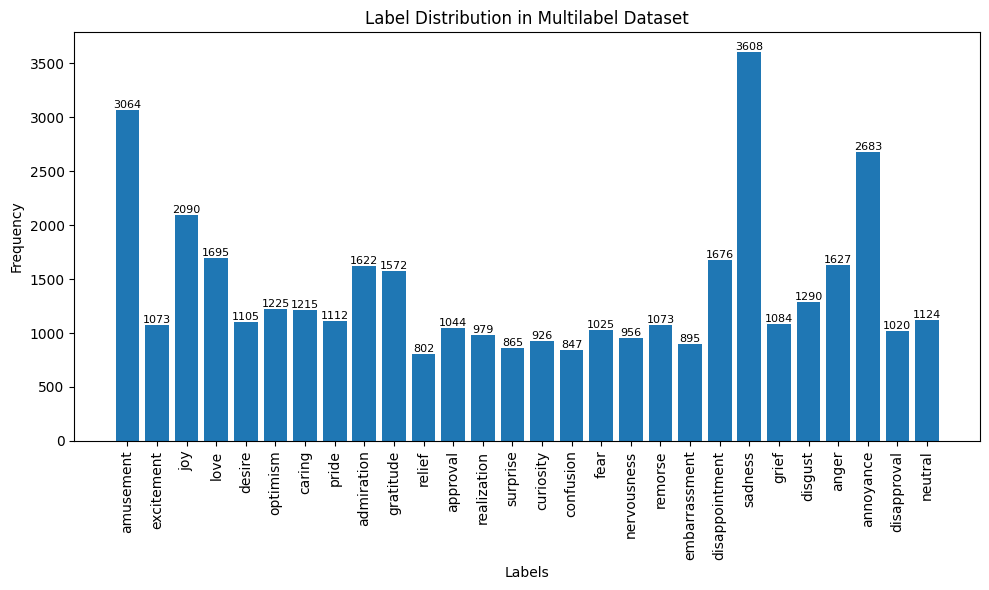

In [22]:
label_frequencies = np.sum(train_labels, axis=0) # calculate the frequency per label
label_names = list(label_dict.values())

plt.figure(figsize=(10, 6))
plt.bar(x=label_names, height=label_frequencies)
for x, y in zip(label_names, label_frequencies):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8)

plt.xlabel('Labels')
plt.ylabel('Frequency')
plt.title('Label Distribution in Multilabel Dataset')
plt.xticks(rotation=90) # Rotate x-axis labels for readibility
plt.tight_layout() # adjust layout to prevent labels from overlapping
plt.show()

## DataLoader

In [23]:
# Select model to deploy
model_type = 'viso' # {'viso': 'visobert', 'pho': 'phobert-base-v2}

In [24]:
if model_type == 'pho':
    print('Create tokenizer for PhoBERT')
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=False)
elif model_type == 'viso':
    print('Create tokenizer for visoBERT')
    tokenizer = AutoTokenizer.from_pretrained("uitnlp/visobert", use_fast=False)
elif model_type == 'cafe':
    print('Create tokenizer for cafeBERT')
    tokenizer = AutoTokenizer.from_pretrained('uitnlp/CafeBERT')
elif model_type == 'vi':
    print('Create tokenizer for viBERT')
    tokenizer = AutoTokenizer.from_pretrained('FPTAI/vibert-base-cased')

tokenizer

Create tokenizer for visoBERT


config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/471k [00:00<?, ?B/s]

XLMRobertaTokenizer(name_or_path='uitnlp/visobert', vocab_size=15002, model_max_length=1000000000000000019884624838656, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	15001: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}
)

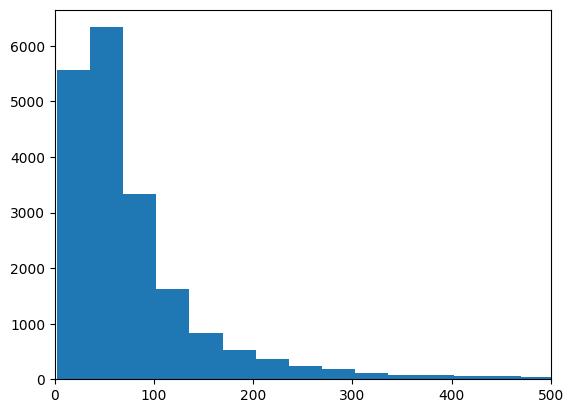

In [25]:
# vẽ biểu đồ thể hiện phân bố chiều dài của câu trong tập dữ liệu.
import matplotlib.pyplot as plt

plt.hist([len(s) for s in train_texts], bins=192)
plt.xlim(0, 500)
plt.show()

In [26]:
lens = [len(tokenizer(t, truncation=False)['input_ids']) for t in train_texts]
p95, p99 = int(np.percentile(lens, 95)), int(np.percentile(lens, 99))
print('token p95/p99:', p95, p99)
max_len = min(256, max(128, p95))

token p95/p99: 75 244


In [27]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128, original_texts=None,
                 e2v=None, include_emoji_vectors=False, emoji_dim=300):
        self.texts = [str(text) for text in texts]
        self.original_texts = [str(text) for text in (original_texts if original_texts is not None else texts)]
        self.labels = torch.tensor(labels, dtype=torch.float)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.e2v = e2v
        self.include_emoji_vectors = include_emoji_vectors
        self.emoji_dim = emoji_dim

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        original_text = self.original_texts[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_attention_mask=True,
            return_token_type_ids=False,
            return_tensors='pt'
        )
        emoji_seq = extract_emoji_sequence(original_text)
        padded_emoji_ids = emoji_seq[:30] + [''] * max(0, 30 - len(emoji_seq))
        
        item = {
            'text': text,
            'original_text': original_text,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'targets': self.labels[idx],
            'emoji_ids': padded_emoji_ids
        }
        return item



def sentiment_collate_fn(batch):
    return {
        'text': [item['text'] for item in batch],
        'original_text': [item['original_text'] for item in batch],
        'input_ids': torch.stack([item['input_ids'] for item in batch]),
        'attention_mask': torch.stack([item['attention_mask'] for item in batch]),
        'targets': torch.stack([item['targets'] for item in batch]),
        'emoji_ids': [list(item['emoji_ids']) for item in batch],
    }


# Datasets and DataLoaders are created inside run_experiment() for each config.


In [28]:
# Dataset previews are performed inside run_experiment() after config-specific creation.

In [29]:
# Global dataset previews removed; run_experiment() owns all datasets.

In [30]:
# Token mapping inspection is deferred to config-specific datasets in run_experiment().

In [31]:
# DataLoaders are created exclusively inside run_experiment() with sentiment_collate_fn.

## Model

In [32]:
# Load tokenizer và model
class ModelSentimentClassifier(nn.Module):
    def __init__(self, n_classes, model_type='pho'):
        super(ModelSentimentClassifier, self).__init__()
        # Select BERT model
        if model_type == 'pho':
            bert_model = 'vinai/phobert-base-v2'
        elif model_type == 'viso':
            bert_model = 'uitnlp/visobert'
        elif model_type == 'cafe':
            bert_model = 'uitnlp/CafeBERT'
        elif model_type == 'vi':
            bert_model = 'FPTAI/vibert-base-cased'

        # Load config with custom dropout settings
        config = AutoConfig.from_pretrained(
            bert_model,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1
        )

        # Download BERT
        self.bert = AutoModel.from_pretrained(bert_model, config=config)
        self.drop = nn.Dropout(p=0.2)
        self.fc = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask, *args, **kwargs):
        last_hidden_state, output = self.bert(
            input_ids = input_ids,
            attention_mask = attention_mask,
            return_dict = False # Dropout sẽ báo lỗi nếu không có điều này
        )

        x = self.drop(output)
        x = self.fc(x)
        return {'logits': x} # add more if needed

model = ModelSentimentClassifier(n_classes=len(label_dict), model_type=model_type).to(device)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = torch.nn.DataParallel(model)
model

# model_bert = "uitnlp/visobert"
# tokenizer = AutoTokenizer.from_pretrained(model_bert, use_fast=False) # https://huggingface.co/uitnlp/visobert
# model = AutoModelForSequenceClassification.from_pretrained(model_bert, num_labels=28) # AutoModelForSequenceClassification, model Bert thêm 2 layers Dense và Dropout với droprate = 0.1.
# model.to(device) # Move model to GPU if GPU is available


2026-06-21 14:35:45.519002: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782052545.943982      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782052546.047067      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782052547.019612      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782052547.019645      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782052547.019647      23 computation_placer.cc:177] computation placer alr

pytorch_model.bin:   0%|          | 0.00/390M [00:00<?, ?B/s]

Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/390M [00:00<?, ?B/s]

Using 2 GPUs


DataParallel(
  (module): ModelSentimentClassifier(
    (bert): XLMRobertaModel(
      (embeddings): XLMRobertaEmbeddings(
        (word_embeddings): Embedding(15004, 768, padding_idx=1)
        (position_embeddings): Embedding(514, 768, padding_idx=1)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): XLMRobertaEncoder(
        (layer): ModuleList(
          (0-11): 12 x XLMRobertaLayer(
            (attention): XLMRobertaAttention(
              (self): XLMRobertaSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): XLMRobertaSelfOutput(
           

In [33]:
# Hàm để tính toán số lượng tham số và phân loại chúng
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params

    # In ra các lớp và tham số trainable/non-trainable
    print(f"\n--- Trainable vs Non-trainable Parameters ---")
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"Trainable: {name} ({param.numel()} parameters)")
        else:
            print(f"Non-trainable: {name} ({param.numel()} parameters)")

    return total_params, trainable_params, non_trainable_params

# Tính toán và hiển thị kết quả
total_params, trainable_params, non_trainable_params = count_parameters(model)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")


--- Trainable vs Non-trainable Parameters ---
Trainable: module.bert.embeddings.word_embeddings.weight (11523072 parameters)
Trainable: module.bert.embeddings.position_embeddings.weight (394752 parameters)
Trainable: module.bert.embeddings.token_type_embeddings.weight (1536 parameters)
Trainable: module.bert.embeddings.LayerNorm.weight (768 parameters)
Trainable: module.bert.embeddings.LayerNorm.bias (768 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.query.weight (589824 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.query.bias (768 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.key.weight (589824 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.key.bias (768 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.value.weight (589824 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.value.bias (768 parameters)
Trainable: module.bert.encoder.layer.0.attention.output.dense.weight (58982

In [34]:
# Optimizer and scheduler are created inside run_experiment() from each experiment config.

## Train and Test

In [35]:
# Loss function: Asymmetric Loss for multi-label classification.
# ASL works directly on logits; pos_weight from BCE is no longer used.
import torch
import torch.nn as nn

class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=0, clip=0.05, eps=1e-8, reduction='mean', pos_class_weight=None):
        super().__init__()
        if reduction not in {'mean', 'sum', 'none'}:
            raise ValueError(f'Unsupported reduction: {reduction}')
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps
        self.reduction = reduction
        if pos_class_weight is None:
            self.register_buffer('pos_class_weight', None)
        else:
            self.register_buffer('pos_class_weight', pos_class_weight.detach().float())

    def forward(self, x, y, pos_class_weight=None):
        if x.shape != y.shape:
            raise ValueError(
                f'logits shape {tuple(x.shape)} != targets shape {tuple(y.shape)}. '
                f'Check that emoji_ids are being passed correctly to the model.'
            )
        y = y.type_as(x)
        p = torch.sigmoid(x)
        p_m = torch.clamp(p - self.clip, min=0.0)
        log_pos = torch.log(torch.clamp(p, min=self.eps))
        log_neg = torch.log(torch.clamp(1.0 - p_m, min=self.eps))
        pos_loss = -y * torch.pow(1.0 - p, self.gamma_pos) * log_pos
        class_weight = self.pos_class_weight if pos_class_weight is None else pos_class_weight
        if class_weight is not None:
            pos_loss = pos_loss * class_weight.to(x.device).view(1, -1)
        neg_loss = -(1.0 - y) * torch.pow(p_m, self.gamma_neg) * log_neg
        loss = pos_loss + neg_loss
        if self.reduction == 'mean':
            return loss.mean()
        if self.reduction == 'sum':
            return loss.sum()
        return loss

loss_fn = AsymmetricLoss(gamma_neg=4, gamma_pos=0, clip=0.05).to(device)
print(loss_fn)


AsymmetricLoss()


In [36]:
class ClusteringContrastiveLoss(nn.Module):
    def __init__(self, tau=0.07, margin=0.3):
        super().__init__()
        self.tau = tau
        self.margin = margin
        self.label_to_cluster = {
            8: 0, 0: 0, 1: 0, 2: 0, 3: 0, 7: 0, 9: 0, 10: 0, 5: 0, 6: 0,
            11: 1, 4: 1,
            24: 2, 25: 2, 23: 2, 26: 2, 19: 2, 16: 2,
            20: 3, 21: 3, 18: 3, 22: 3,
            15: 4, 14: 4, 12: 4, 13: 4,
            27: 5
        }
        M = torch.zeros(28, 6)
        for label_idx, cluster_idx in self.label_to_cluster.items():
            M[label_idx, cluster_idx] = 1.0
        self.register_buffer('M', M)

    def forward(self, z, y):
        B = z.size(0)
        if B <= 1:
            return torch.tensor(0.0, device=z.device)
        S = torch.matmul(y, self.M)
        S_bin = (S > 0).float()
        shared = torch.matmul(S_bin, S_bin.T)
        shared_mask = (shared > 0).float()
        identity_mask = torch.eye(B, device=z.device)
        pos_mask = shared_mask * (1.0 - identity_mask)
        neg_mask = (1.0 - shared_mask) * (1.0 - identity_mask)
        similarity_matrix = torch.matmul(z, z.T)
        logits_sim = similarity_matrix / self.tau
        logits_sim = logits_sim.masked_fill(
            torch.eye(B, dtype=torch.bool, device=z.device), float('-inf')
        )
        log_sum_k = torch.logsumexp(logits_sim, dim=-1, keepdim=True)
        L_pos_matrix = log_sum_k - logits_sim
        pos_losses = L_pos_matrix[pos_mask.bool()]
        L_neg_matrix = torch.clamp(similarity_matrix - self.margin, min=0.0)
        neg_losses = L_neg_matrix[neg_mask.bool()]
        mean_pos = torch.mean(pos_losses) if pos_losses.numel() > 0 else torch.tensor(0.0, device=z.device)
        mean_neg = torch.mean(neg_losses) if neg_losses.numel() > 0 else torch.tensor(0.0, device=z.device)
        return mean_pos + mean_neg

class LabelDescriptionLoss(nn.Module):
    def __init__(self, backbone, tokenizer, device, tau=0.07):
        super().__init__()
        self.tau = tau
        self.tokenizer = tokenizer
        self.descriptions = [
            'amusement: cảm xúc vui vẻ, giải trí và gây cười nhẹ nhàng',
            'excitement: cảm giác hào hứng, phấn khích trước điều gì đó thú vị',
            'joy: niềm vui sướng, hạnh phúc tràn ngập năng lượng tích cực',
            'love: tình yêu thương và sự gắn bó sâu sắc dành cho người khác',
            'desire: khao khát hoặc thèm muốn có được một điều gì đó',
            'optimism: sự lạc quan và niềm tin vào tương lai tươi sáng',
            'caring: sự quan tâm, chăm sóc và lo lắng cho người khác',
            'pride: lòng tự hào và sự tự tôn về bản thân hoặc thành tựu',
            'admiration: sự ngưỡng mộ, kính trọng và đánh giá cao người khác',
            'gratitude: sự biết ơn sâu sắc trước sự giúp đỡ hay lòng tốt',
            'relief: cảm giác nhẹ nhõm khi trút bỏ được lo lắng căng thẳng',
            'approval: sự tán thành, đồng ý và ủng hộ ý kiến hành động',
            'realization: sự nhận ra, thấu hiểu hoặc phát hiện mới mẻ',
            'surprise: sự ngạc nhiên, bất ngờ trước việc không ngờ tới',
            'curiosity: sự tò mò, ham học hỏi và tìm hiểu mọi thứ',
            'confusion: sự bối rối, hoang mang chưa hiểu rõ vấn đề',
            'fear: nỗi sợ hãi, lo lắng trước mối nguy hiểm đe dọa',
            'nervousness: sự lo lắng, bồn chồn trước một sự kiện sắp diễn ra',
            'remorse: sự hối hận, ăn năn tự trách về lỗi lầm đã qua',
            'embarrassment: sự ngượng ngùng, xấu hổ trước mặt người khác',
            'disappointment: sự thất vọng khi kết quả không như ý muốn',
            'sadness: nỗi buồn bã, u sầu và chán nản trong lòng',
            'grief: sự đau buồn sâu sắc trước mất mát lớn lao',
            'disgust: sự ghê tởm, khó chịu trước điều bẩn thỉu xấu xa',
            'anger: sự tức giận, giận dữ phẫn nộ mạnh mẽ',
            'annoyance: sự khó chịu, bực mình vì phiền toái nhỏ nhặt',
            'disapproval: sự phản đối, không chấp nhận một hành vi nào đó',
            'neutral: trạng thái trung tính bình thường không có cảm xúc đặc biệt'
        ]
        hidden_size = getattr(backbone.config, 'hidden_size', None) or getattr(backbone.config, 'dim', None)
        self.register_buffer('d_k', torch.empty(len(self.descriptions), hidden_size, device=device))
        self.refresh(backbone, device)

    def refresh(self, backbone, device):
        was_training = backbone.training
        backbone.eval()
        with torch.no_grad():
            inputs = self.tokenizer(
                self.descriptions, padding=True, truncation=True, return_tensors='pt'
            ).to(device)
            outputs = backbone(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'])
            H = outputs.last_hidden_state
            m = inputs['attention_mask'].unsqueeze(-1).float()
            d_k = (H * m).sum(1) / m.sum(1).clamp(min=1e-9)
            d_k = torch.nn.functional.normalize(d_k, p=2, dim=-1)
            self.d_k.copy_(d_k)
        if was_training:
            backbone.train()

    def forward(self, z, y):
        logits = torch.matmul(z, self.d_k.T) / self.tau
        return F.binary_cross_entropy_with_logits(logits, y.float())

def _base_model(model):
    return model.module if isinstance(model, torch.nn.DataParallel) else model


def _prepare_emoji_vectors(model, emoji_ids, device):
    m = _base_model(model)
    use_emoji_branch = bool(getattr(m, 'use_emoji_branch', hasattr(m, 'emoji_encoder')))
    if not use_emoji_branch or emoji_ids is None:
        return None
    emoji_encoder = getattr(m, 'emoji_encoder', None)
    if emoji_encoder is None:
        return None
    return emoji_encoder(emoji_ids, device=device)


def get_logits(model, data, device='cpu', emoji_vectors=None):
    input_ids = data['input_ids'].to(device)
    attention_mask = data['attention_mask'].to(device)
    emoji_ids = data.get('emoji_ids', None)
    m = _base_model(model)

    if emoji_vectors is None:
        emoji_vectors = _prepare_emoji_vectors(model, emoji_ids, device)

    import inspect
    sig = inspect.signature(m.forward)
    forward_kwargs = {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
    }
    if emoji_vectors is not None and 'emoji_vectors' in sig.parameters:
        forward_kwargs['emoji_vectors'] = emoji_vectors
    elif emoji_ids is not None and not isinstance(model, torch.nn.DataParallel) and 'emoji_ids' in sig.parameters:
        forward_kwargs['emoji_ids'] = emoji_ids
    outputs = model(**forward_kwargs)
        
    # Robustly unpack outputs to guarantee logits is a Tensor
    logits = None
    cls_embedding = None
    
    if isinstance(outputs, dict):
        logits = outputs.get('logits')
        cls_embedding = outputs.get('cls_embedding')
    elif hasattr(outputs, 'logits'):
        logits = outputs.logits
        cls_embedding = getattr(outputs, 'cls_embedding', getattr(outputs, 'pooled', None))
    elif isinstance(outputs, (tuple, list)):
        if len(outputs) > 0:
            logits = outputs[0]
        if len(outputs) > 1:
            cls_embedding = outputs[1]
    elif isinstance(outputs, torch.Tensor):
        logits = outputs
        
    return logits, cls_embedding
def _binary_sym_kl(logits_a, logits_b, eps=1e-6):
    pa = torch.sigmoid(logits_a).clamp(eps, 1 - eps)
    pb = torch.sigmoid(logits_b).clamp(eps, 1 - eps)
    kl_ab = pa * (torch.log(pa) - torch.log(pb)) + (1 - pa) * (torch.log(1 - pa) - torch.log(1 - pb))
    kl_ba = pb * (torch.log(pb) - torch.log(pa)) + (1 - pb) * (torch.log(1 - pb) - torch.log(1 - pa))
    return 0.5 * (kl_ab + kl_ba).mean()


def train(model, data_loader, loss_fn, optimizer, device='cpu', threshold=0.5, use_rdrop=False, alpha_rdrop=5.0, use_taco=False, ccl_fn=None, ldl_fn=None, lambda_ccl=0.1, lambda_ldl=0.1, lr_scheduler=None, epoch=0):
    model.train()
    losses = []
    all_targets = []
    all_preds = []
    for data in data_loader:
        targets = data['targets'].to(device)
        emoji_ids = data.get('emoji_ids', None)
        emoji_vectors = _prepare_emoji_vectors(model, emoji_ids, device)
        optimizer.zero_grad()
        if use_rdrop:
            logits1, cls1 = get_logits(model, data, device=device, emoji_vectors=emoji_vectors)
            logits2, cls2 = get_logits(model, data, device=device, emoji_vectors=emoji_vectors)
            L_main = 0.5 * (loss_fn(logits1, targets) + loss_fn(logits2, targets))
            loss = L_main + alpha_rdrop * _binary_sym_kl(logits1, logits2)
            logits_for_pred = logits1
            cls_for_taco = cls1
        else:
            logits_for_pred, cls_for_taco = get_logits(model, data, device=device, emoji_vectors=emoji_vectors)
            loss = loss_fn(logits_for_pred, targets)
        if use_taco and epoch > 0 and cls_for_taco is not None:
            z = torch.nn.functional.normalize(cls_for_taco, p=2, dim=-1)
            loss_ccl = ccl_fn(z, targets) if ccl_fn is not None else 0.0
            loss_ldl = ldl_fn(z, targets) if ldl_fn is not None else 0.0
            loss = loss + lambda_ccl * loss_ccl + lambda_ldl * loss_ldl
        losses.append(loss.item())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if lr_scheduler is not None:
            lr_scheduler.step()
        preds = torch.sigmoid(logits_for_pred)
        preds = (preds >= threshold).int()
        all_targets.append(targets.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    mean_loss = np.mean(losses)
    correct_per_label = (all_targets == all_preds).sum(axis=0)
    average_accuracy = (correct_per_label / all_targets.shape[0]).mean()
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    print(f'Train Loss: {mean_loss:.4f} | Average Accuracy: {average_accuracy:.4f} | Macro F1: {macro_f1:.4f}')
    return mean_loss, average_accuracy, macro_f1

def eval_model(model, data_loader, loss_fn, device='cpu', threshold=0.5):
    model.eval()
    losses = []
    all_targets = []
    all_preds = []
    with torch.no_grad():
        for data in data_loader:
            targets = data['targets'].to(device)
            logits, _ = get_logits(model, data, device=device)
            loss = loss_fn(logits, targets)
            losses.append(loss.item())
            preds = torch.sigmoid(logits)
            preds = (preds >= threshold).int()
            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    mean_loss = np.mean(losses)
    correct_per_label = (all_targets == all_preds).sum(axis=0)
    average_accuracy = (correct_per_label / all_targets.shape[0]).mean()
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    print(f'Validation Loss: {mean_loss:.4f} | Average Accuracy: {average_accuracy:.4f} | Macro F1: {macro_f1:.4f}')
    return mean_loss, average_accuracy, macro_f1

def test_model(model, data_loader, device='cpu', threshold=0.5):
    model.to(device)
    model.eval()
    texts, original_texts, predict_probs, predicts, real_values = [], [], [], [], []
    with torch.no_grad():
        for data in data_loader:
            targets = data['targets'].to(device)
            logits, _ = get_logits(model, data, device=device)
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int()
            texts.extend(data['text'])
            original_texts.extend(data.get('original_text', data['text']))
            predicts.extend(preds.cpu().numpy())
            predict_probs.extend(probs.cpu().numpy())
            real_values.extend(targets.cpu().numpy())
    predicts = torch.tensor(np.asarray(predicts))
    predict_probs = torch.tensor(np.asarray(predict_probs))
    real_values = torch.tensor(np.asarray(real_values))
    return predict_probs, predicts, real_values


In [37]:
def eval_model(model, data_loader, loss_fn, device='cpu', threshold=0.5):
    model.eval()
    losses = []
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for data in data_loader:
            targets = data['targets'].to(device)
            logits, _ = get_logits(model, data, device=device)

            loss = loss_fn(logits, targets)
            losses.append(loss.item())

            preds = torch.sigmoid(logits)
            preds = (preds >= threshold).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    mean_loss = np.mean(losses)
    correct_per_label = (all_targets == all_preds).sum(axis=0)
    total_per_label = all_targets.shape[0]
    label_accuracies = correct_per_label / total_per_label
    average_accuracy = label_accuracies.mean()
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

    print(f'Validation Loss: {mean_loss:.4f} | Average Accuracy: {average_accuracy:.4f} | Macro F1: {macro_f1:.4f}')
    return mean_loss, average_accuracy, macro_f1


eval = eval_model


In [38]:
def test_model(model, data_loader, device='cpu', threshold=0.5):
    model.to(device)
    model.eval()
    texts, original_texts, predict_probs, predicts, real_values = [], [], [], [], []

    with torch.no_grad():
        for data in data_loader:
            targets = data['targets'].to(device)
            logits, _ = get_logits(model, data, device=device)

            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int()

            texts.extend(data['text'])
            original_texts.extend(data.get('original_text', data['text']))
            predicts.extend(preds.cpu().numpy())
            predict_probs.extend(probs.cpu().numpy())
            real_values.extend(targets.cpu().numpy())

    predicts = torch.tensor(np.asarray(predicts))
    predict_probs = torch.tensor(np.asarray(predict_probs))
    real_values = torch.tensor(np.asarray(real_values))

    return predict_probs, predicts, real_values


test = test_model


In [39]:
import os

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("checkpoints folder ready")
!ls /kaggle/working

checkpoints folder ready
checkpoints  __notebook__.ipynb  reports  results


In [40]:
# Unified Experiment Runner and Ablation Study Setup
import time
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

def find_optimal_thresholds_per_class(probs, targets, grid=None, min_support=10,
                                      lo=0.15, hi=0.85, default=0.5):
    if grid is None:
        grid = np.arange(0.05, 0.95, 0.01)
    n_classes = probs.shape[1]
    best_t = np.full(n_classes, default, dtype=float)
    for c in range(n_classes):
        if targets[:, c].sum() < min_support:
            best_t[c] = default
            continue
        best_f1 = -1.0
        for t in grid:
            f1 = f1_score(targets[:, c], (probs[:, c] >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t[c] = f1, t
        best_t[c] = float(np.clip(best_t[c], lo, hi))
    return best_t

def save_classification_outputs(real_values, predicts, report_path, title):
    labels = list(label_dict.values())
    report = classification_report(
        real_values,
        predicts,
        target_names=labels,
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report).transpose()
    report_df.index.name = 'class'
    
    # Ensure parent directory exists
    parent_dir = os.path.dirname(report_path)
    if parent_dir:
        os.makedirs(parent_dir, exist_ok=True)
        
    report_df.to_csv(report_path)

    test_macro_f1 = f1_score(real_values, predicts, average='macro', zero_division=0)
    per_class_f1 = report_df.loc[labels, 'f1-score']

    print(title)
    print(classification_report(real_values, predicts, target_names=labels, zero_division=0))
    print('Test Macro F1:', test_macro_f1)
    return report_df, test_macro_f1
def safe_torch_load(path, device):
    try:
        return torch.load(path, weights_only=True, map_location=device)
    except Exception as weights_only_error:
        print(f'weights_only=True could not load {path}; retrying legacy module checkpoint.')
        try:
            return torch.load(path, weights_only=False, map_location=device)
        except Exception:
            raise weights_only_error


def load_checkpoint_as_model(path, model_cls, model_kwargs, device):
    checkpoint = safe_torch_load(path, device)
    if isinstance(checkpoint, nn.Module):
        checkpoint.to(device)
        return checkpoint
    if isinstance(checkpoint, dict):
        for key in ('model_state_dict', 'state_dict', 'model'):
            if key in checkpoint:
                state_dict = checkpoint[key]
                break
        else:
            state_dict = checkpoint
            
        cleaned = {}
        for k, v in state_dict.items():
            cleaned[k.replace('module.', '', 1)] = v
            
        # Detect checkpoint architecture type
        actual_cls = model_cls
        actual_kwargs = dict(model_kwargs)
        if "bert.embeddings.word_embeddings.weight" in cleaned or "emoji_projection.0.weight" in cleaned:
            print("Detected EmojiAwareViSoBERT checkpoint architecture. Dynamically loading as EmojiAwareViSoBERT.")
            actual_cls = EmojiAwareViSoBERT
            actual_kwargs = {
                'model_name': model_kwargs.get('model_name', 'uitnlp/visobert'),
                'num_labels': model_kwargs.get('num_labels', 28),
                'emoji_dim': model_kwargs.get('emoji_dim', 300),
                'dropout': model_kwargs.get('dropout', 0.2),
                'e2v': model_kwargs.get('e2v', None)
            }
            
        model = actual_cls(**actual_kwargs).to(device)
        model.load_state_dict(cleaned, strict=True)
        return model
    raise TypeError(f'Unexpected checkpoint type: {type(checkpoint)}')


EXPERIMENT_BUNDLE_DIR = os.path.join(WORKING_DIR, 'experiment_bundles')
os.makedirs(EXPERIMENT_BUNDLE_DIR, exist_ok=True)


def _json_safe(value):
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    return value


def _bundle_dir(name, seed):
    safe_name = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(name))
    return os.path.join(EXPERIMENT_BUNDLE_DIR, f'{safe_name}__seed{seed}')


def save_experiment_bundle(result):
    bundle_dir = _bundle_dir(result['name'], result.get('seed', 42))
    os.makedirs(bundle_dir, exist_ok=True)
    array_keys = (
        'val_probs', 'val_targets', 'test_probs', 'test_targets',
        'optimal_thresholds',
    )
    for key in array_keys:
        np.save(os.path.join(bundle_dir, f'{key}.npy'), np.asarray(result[key]))

    metadata = {
        key: _json_safe(value)
        for key, value in result.items()
        if key not in array_keys
    }
    metadata['bundle_version'] = 1
    metadata['array_keys'] = list(array_keys)
    with open(os.path.join(bundle_dir, 'result.json'), 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)

    manifest_path = os.path.join(WORKING_DIR, 'resume_manifest.json')
    manifest = []
    if os.path.exists(manifest_path):
        try:
            with open(manifest_path, 'r', encoding='utf-8') as f:
                manifest = json.load(f)
        except (OSError, json.JSONDecodeError):
            manifest = []
    manifest = [
        item for item in manifest
        if not (
            item.get('name') == result['name']
            and int(item.get('seed', 42)) == int(result.get('seed', 42))
        )
    ]
    manifest.append({
        'name': result['name'],
        'seed': int(result.get('seed', 42)),
        'bundle': os.path.relpath(bundle_dir, WORKING_DIR),
        'checkpoint': os.path.basename(str(result.get('checkpoint_path', ''))),
        'test_macro_f1': float(result['test_macro_f1']),
        'best_val_f1': float(result['best_val_f1']),
    })
    with open(manifest_path, 'w', encoding='utf-8') as f:
        json.dump(manifest, f, indent=2, ensure_ascii=False)
    print(f'Saved resumable experiment bundle: {bundle_dir}')
    return bundle_dir


def _iter_result_json_files():
    roots = [EXPERIMENT_BUNDLE_DIR]
    if os.path.isdir('/kaggle/input'):
        roots.append('/kaggle/input')
    seen = set()
    for root in roots:
        if not os.path.isdir(root):
            continue
        for current_root, _, files in os.walk(root):
            if 'result.json' not in files:
                continue
            result_path = os.path.join(current_root, 'result.json')
            if result_path not in seen:
                seen.add(result_path)
                yield result_path


def load_experiment_bundle(name, seed=42):
    for result_path in _iter_result_json_files():
        try:
            with open(result_path, 'r', encoding='utf-8') as f:
                metadata = json.load(f)
        except (OSError, json.JSONDecodeError):
            continue
        if metadata.get('name') != name or int(metadata.get('seed', 42)) != int(seed):
            continue
        bundle_dir = os.path.dirname(result_path)
        result = dict(metadata)
        try:
            for key in metadata.get('array_keys', []):
                result[key] = np.load(os.path.join(bundle_dir, f'{key}.npy'))
        except (OSError, ValueError):
            continue
        result['bundle_dir'] = bundle_dir
        print(f'Resuming completed experiment from bundle: {bundle_dir}')
        return result
    return None


def _find_uploaded_file(filename, path_contains=None):
    search_roots = [WORKING_DIR]
    if os.path.isdir('/kaggle/input'):
        search_roots.append('/kaggle/input')
    for root in search_roots:
        for current_root, _, files in os.walk(root):
            if filename in files:
                candidate = os.path.join(current_root, filename)
                if path_contains is None or path_contains in candidate:
                    return candidate
    return None


def recover_completed_experiment(cfg):
    name = cfg['name']
    seed = cfg.get('seed', 42)
    checkpoint_name = f'{name}_seed{seed}.pth'
    report_name = f'{name}_classification_report.csv'
    checkpoint_path = _find_uploaded_file(checkpoint_name)
    completed_report_path = _find_uploaded_file(report_name)
    if checkpoint_path is None or completed_report_path is None:
        return None

    print(f'Recovering completed experiment by inference: {name}, seed={seed}')
    use_emoji_branch = cfg.get('use_emoji_branch', False)
    e2v_loc = None
    if use_emoji_branch:
        emoji2vec_path = os.path.join(DATA_ROOT, 'emoji2vec.bin')
        e2v_loc = load_emoji2vec(emoji2vec_path)

    val_ds = SentimentDataset(
        val_texts, val_labels, tokenizer, max_len=max_len,
        original_texts=val_original_texts, e2v=e2v_loc,
        include_emoji_vectors=use_emoji_branch,
    )
    test_ds = SentimentDataset(
        test_texts, test_labels, tokenizer, max_len=max_len,
        original_texts=test_original_texts, e2v=e2v_loc,
        include_emoji_vectors=use_emoji_branch,
    )
    val_ldr = DataLoader(
        val_ds, batch_size=32, shuffle=False, num_workers=2,
        collate_fn=sentiment_collate_fn,
    )
    test_ldr = DataLoader(
        test_ds, batch_size=32, shuffle=False, num_workers=2,
        collate_fn=sentiment_collate_fn,
    )
    model = load_checkpoint_as_model(checkpoint_path, ViSoBertMultiLabel, {
        'model_name': 'uitnlp/visobert',
        'num_labels': len(label_dict),
        'dropout': cfg.get('dropout', 0.2),
        'use_emoji_branch': use_emoji_branch,
        'e2v': e2v_loc,
        'emoji_dim': 300,
    }, device)
    val_probs, _, val_targets = test_model(model, val_ldr, device, threshold=0.5)
    test_probs, _, test_targets = test_model(model, test_ldr, device, threshold=0.5)
    val_probs_np = val_probs.numpy()
    val_targets_np = val_targets.numpy().astype(int)
    test_probs_np = test_probs.numpy()
    test_targets_np = test_targets.numpy().astype(int)

    threshold_file = _find_uploaded_file('thresholds.json', path_contains=name)
    optimal_thresholds = None
    if threshold_file:
        try:
            with open(threshold_file, 'r', encoding='utf-8') as f:
                threshold_dict = json.load(f)
            optimal_thresholds = np.asarray([
                threshold_dict[label] for label in label_dict.values()
            ], dtype=float)
        except (OSError, KeyError, ValueError, json.JSONDecodeError):
            optimal_thresholds = None
    if optimal_thresholds is None:
        optimal_thresholds = find_optimal_thresholds_per_class(val_probs_np, val_targets_np)

    val_preds = (val_probs_np >= optimal_thresholds.reshape(1, -1)).astype(int)
    test_preds_p50 = (test_probs_np >= 0.5).astype(int)
    test_preds = (test_probs_np >= optimal_thresholds.reshape(1, -1)).astype(int)
    test_per_class_f1 = f1_score(
        test_targets_np, test_preds, average=None, zero_division=0
    )
    weak_classes = [
        'disapproval', 'neutral', 'disappointment',
        'nervousness', 'confusion', 'realization',
    ]
    weak_indices = {name: int(idx) for idx, name in label_dict.items() if name in weak_classes}
    weak_class_f1s = {
        class_name: float(test_per_class_f1[idx])
        for class_name, idx in weak_indices.items()
    }
    result = {
        'name': name,
        'val_f1_history': [],
        'best_epoch': 'uploaded',
        'best_val_f1': f1_score(
            val_targets_np, val_preds, average='macro', zero_division=0
        ),
        'test_macro_f1_p50': f1_score(
            test_targets_np, test_preds_p50, average='macro', zero_division=0
        ),
        'test_macro_f1': f1_score(
            test_targets_np, test_preds, average='macro', zero_division=0
        ),
        'test_precision': precision_score(
            test_targets_np, test_preds, average='macro', zero_division=0
        ),
        'test_recall': recall_score(
            test_targets_np, test_preds, average='macro', zero_division=0
        ),
        'test_weighted_f1': f1_score(
            test_targets_np, test_preds, average='weighted', zero_division=0
        ),
        'weak_class_f1s': weak_class_f1s,
        'weak_class_mean_f1': float(np.mean(list(weak_class_f1s.values()))),
        'training_time': 0.0,
        'seed': seed,
        'checkpoint_path': checkpoint_path,
        'threshold_path': threshold_file or '',
        'optimal_thresholds': optimal_thresholds,
        'val_probs': val_probs_np,
        'val_targets': val_targets_np,
        'test_probs': test_probs_np,
        'test_targets': test_targets_np,
        'config': dict(cfg),
    }
    save_experiment_bundle(result)
    return result


def run_or_resume_experiment(cfg):
    seed = cfg.get('seed', 42)
    result = load_experiment_bundle(cfg['name'], seed)
    if result is not None:
        return result
    result = recover_completed_experiment(cfg)
    if result is not None:
        return result
    result = load_or_run(cfg, run_experiment)
    save_experiment_bundle(result)
    return result

def run_experiment(cfg):
    print("=" * 60)
    print(f"RUNNING EXPERIMENT: {cfg['name']}")
    print("=" * 60)
    
    seed = cfg.get('seed', 42)
    set_seed(seed)
    
    use_asl = cfg.get("use_asl", True)
    use_taco = cfg.get("use_taco", False)
    use_emoji_branch = cfg.get("use_emoji_branch", False)
    use_rdrop = cfg.get("use_rdrop", False)
    alpha_rdrop = cfg.get("rdrop_alpha", cfg.get("alpha_rdrop", 5.0))
    optimize_threshold = True
    use_cb = cfg.get("use_cb", False)
    epochs = cfg.get("epochs", 10)
    lr = cfg.get("lr", 2e-5)
    weight_decay = cfg.get("weight_decay", 0.0)
    dropout = cfg.get("dropout", 0.2)
    gamma_neg = cfg.get("gamma_neg", 4)
    gamma_pos = cfg.get("gamma_pos", 0)
    clip = cfg.get("clip", 0.05)
    early_stopping_patience = cfg.get("early_stopping_patience", 3)
    differential_lr = cfg.get("differential_lr", False)
    taco_tau = cfg.get("taco_tau", 0.07)
    taco_margin = cfg.get("taco_margin", 0.3)
    lambda_ccl = cfg.get("lambda_ccl", 0.1)
    lambda_ldl = cfg.get("lambda_ldl", 0.1)
    
    e2v_loc = None
    if use_emoji_branch:
        emoji2vec_path = os.path.join(DATA_ROOT, 'emoji2vec.bin')
        if not os.path.exists(emoji2vec_path):
            emoji2vec_path = 'data/emoji2vec.bin'
        e2v_loc = load_emoji2vec(emoji2vec_path)
        
    train_ds = SentimentDataset(
        train_texts, train_labels, tokenizer, max_len=max_len,
        original_texts=train_original_texts, e2v=e2v_loc, include_emoji_vectors=use_emoji_branch,
    )
    val_ds = SentimentDataset(
        val_texts, val_labels, tokenizer, max_len=max_len,
        original_texts=val_original_texts, e2v=e2v_loc, include_emoji_vectors=use_emoji_branch,
    )
    test_ds = SentimentDataset(
        test_texts, test_labels, tokenizer, max_len=max_len,
        original_texts=test_original_texts, e2v=e2v_loc, include_emoji_vectors=use_emoji_branch,
    )
    
    train_ldr = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, collate_fn=sentiment_collate_fn)
    val_ldr = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, collate_fn=sentiment_collate_fn)
    test_ldr = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, collate_fn=sentiment_collate_fn)
    
    model = ViSoBertMultiLabel(
        model_name='uitnlp/visobert',
        num_labels=len(label_dict),
        dropout=dropout,
        use_emoji_branch=use_emoji_branch,
        e2v=e2v_loc,
        emoji_dim=300,
    ).to(device)
    
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for training")
        model = torch.nn.DataParallel(model)
        
    cb_w = None
    if use_cb:
        counts = np.sum(train_labels, axis=0)
        beta = 0.999
        cb_w_np = (1 - beta) / (1 - np.power(beta, np.maximum(counts, 1)))
        cb_w_np = cb_w_np / cb_w_np.mean()
        cb_w = torch.tensor(cb_w_np, dtype=torch.float32, device=device)

    if use_asl:
        loss_fn = AsymmetricLoss(
            gamma_neg=gamma_neg, gamma_pos=gamma_pos, clip=clip,
            pos_class_weight=cb_w
        ).to(device)
    else:
        label_counts = np.sum(train_labels, axis=0)
        total_samples = len(train_labels)
        pos_weight = torch.tensor([(total_samples - count) / max(count, 1e-8) for count in label_counts]).to(device)
        loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
    ccl_fn = ClusteringContrastiveLoss(tau=taco_tau, margin=taco_margin).to(device) if use_taco else None
    ldl_fn = LabelDescriptionLoss(
        model.backbone if not isinstance(model, torch.nn.DataParallel) else model.module.backbone, 
        tokenizer, device, tau=taco_tau
    ).to(device) if use_taco else None
    
    if differential_lr:
        m = model.module if isinstance(model, torch.nn.DataParallel) else model
        bert_params = list(m.backbone.parameters())
        head_params = list(m.classifier.parameters())
        if use_emoji_branch:
            head_params.extend(list(m.emoji_encoder.parameters()))
        optimizer = AdamW([
            {'params': bert_params, 'lr': lr},
            {'params': head_params, 'lr': 5e-5}
        ], weight_decay=weight_decay)
    else:
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        
    lr_scheduler = get_scheduler(
        'linear', optimizer=optimizer, 
        num_warmup_steps=len(train_ldr), 
        num_training_steps=len(train_ldr) * epochs
    )
    
    best_val_f1 = -1.0
    best_epoch = 0
    patience_counter = 0
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{cfg['name']}_seed{seed}.pth")
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    artifacts_dir = os.path.join(WORKING_DIR, 'artifacts', cfg['name'])
    os.makedirs(artifacts_dir, exist_ok=True)
    threshold_path = os.path.join(artifacts_dir, 'thresholds.json')
    
    weak_classes = ['disapproval', 'neutral', 'disappointment', 'nervousness', 'confusion', 'realization']
    weak_indices = {name: int(idx) for idx, name in label_dict.items() if name in weak_classes}
    
    val_f1_history = []
    val_f1_p50_history = []
    best_thresholds = np.full(len(label_dict), 0.5, dtype=float)
    start_time = time.time()
    
    for epoch in range(epochs):
        if use_taco and epoch > 0 and ldl_fn is not None:
            ldl_fn.refresh(_base_model(model).backbone, device)
        train_loss, train_acc, train_f1 = train(
            model, train_ldr, loss_fn, optimizer, device, threshold=0.5,
            use_rdrop=use_rdrop, alpha_rdrop=alpha_rdrop,
            use_taco=use_taco, ccl_fn=ccl_fn, ldl_fn=ldl_fn, lambda_ccl=lambda_ccl, lambda_ldl=lambda_ldl,
            lr_scheduler=lr_scheduler, epoch=epoch
        )
        val_loss, val_acc, val_f1_p50 = eval_model(model, val_ldr, loss_fn, device, threshold=0.5)
        val_probs, _, val_targets = test_model(model, val_ldr, device, threshold=0.5)
        val_probs_np = val_probs.numpy()
        val_targets_np = val_targets.numpy().astype(int)
        epoch_thresholds = find_optimal_thresholds_per_class(val_probs_np, val_targets_np)
        val_preds_tuned = (val_probs_np >= epoch_thresholds.reshape(1, -1)).astype(int)
        val_macro_tuned = f1_score(
            val_targets_np, val_preds_tuned, average='macro', zero_division=0
        )
        val_f1_history.append(val_macro_tuned)
        val_f1_p50_history.append(val_f1_p50)
        print(f'Epoch {epoch+1} Val Macro F1 @0.5: {val_f1_p50:.4f} | tuned: {val_macro_tuned:.4f}')
        
        # Log per-class F1 for weakest classes using tuned validation thresholds
        per_class_f1 = f1_score(val_targets_np, val_preds_tuned, average=None, zero_division=0)
        print(f"Epoch {epoch+1} - Weak classes Val F1:")
        for name, idx in weak_indices.items():
            print(f"  {name}: {per_class_f1[idx]:.4f}")
            
        if val_macro_tuned > best_val_f1:
            best_val_f1 = val_macro_tuned
            best_epoch = epoch + 1
            patience_counter = 0
            best_thresholds = epoch_thresholds.copy()
            print(f"Tuned val F1 improved to {val_macro_tuned:.4f}. Saving checkpoint to {checkpoint_path}...")
            model_to_save = _base_model(model)
            torch.save({'model_state_dict': model_to_save.state_dict()}, checkpoint_path)
            labels = list(label_dict.values())
            thresholds_dict = {labels[i]: float(best_thresholds[i]) for i in range(len(labels))}
            with open(threshold_path, 'w', encoding='utf-8') as f:
                json.dump(thresholds_dict, f, indent=4, ensure_ascii=False)
        else:
            patience_counter += 1
            print(f"Tuned val F1 did not improve. Patience: {patience_counter}/{early_stopping_patience}")
            if patience_counter >= early_stopping_patience:
                print("Early stopping triggered.")
                break
                
    training_time = time.time() - start_time
    print(f"Training finished in {training_time:.2f} seconds.")
    
    # Load best checkpoint
    print(f"Loading best checkpoint for final evaluation: {checkpoint_path}")
    best_model = load_checkpoint_as_model(checkpoint_path, ViSoBertMultiLabel, {
        'model_name': 'uitnlp/visobert',
        'num_labels': len(label_dict),
        'dropout': dropout,
        'use_emoji_branch': use_emoji_branch,
        'e2v': e2v_loc,
        'emoji_dim': 300
    }, device)
    
    # Reuse thresholds from the best tuned-validation epoch.
    val_probs, _, val_targets = test_model(best_model, val_ldr, device, threshold=0.5)
    val_probs_np = val_probs.numpy()
    val_targets_np = val_targets.numpy().astype(int)
    optimal_thresholds = best_thresholds.copy()
        
    test_probs, _, test_targets = test_model(best_model, test_ldr, device, threshold=0.5)
    test_probs_np = test_probs.numpy()
    test_targets_np = test_targets.numpy().astype(int)
    
    test_preds_p50 = (test_probs_np >= 0.5).astype(int)
    test_preds = (test_probs_np >= optimal_thresholds.reshape(1, -1)).astype(int)
    test_macro_f1_p50 = f1_score(
        test_targets_np, test_preds_p50, average='macro', zero_division=0
    )
    test_macro_f1_tuned = f1_score(
        test_targets_np, test_preds, average='macro', zero_division=0
    )
    print(f"{cfg['name']} Test Macro F1 @0.5: {test_macro_f1_p50:.4f}")
    print(f"{cfg['name']} Test Macro F1 @tuned: {test_macro_f1_tuned:.4f}")
    print('Best validation thresholds:')
    print(json.dumps({list(label_dict.values())[i]: float(optimal_thresholds[i]) for i in range(len(label_dict))}, indent=2, ensure_ascii=False))
        
    report_path = os.path.join(REPORT_DIR, f"{cfg['name']}_classification_report.csv")
    report_df, test_macro_f1 = save_classification_outputs(
        test_targets_np,
        test_preds,
        report_path,
        f"Classification Report - {cfg['name']}"
    )
    
    test_precision = precision_score(test_targets_np, test_preds, average='macro', zero_division=0)
    test_recall = recall_score(test_targets_np, test_preds, average='macro', zero_division=0)
    test_weighted_f1 = f1_score(test_targets_np, test_preds, average='weighted', zero_division=0)
    
    test_per_class_f1 = f1_score(test_targets_np, test_preds, average=None, zero_division=0)
    weak_class_f1s = {name: float(test_per_class_f1[idx]) for name, idx in weak_indices.items()}
    weak_class_mean_f1 = float(np.mean(list(weak_class_f1s.values())))
    
    result = {
        "name": cfg["name"],
        "val_f1_history": val_f1_history,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "test_macro_f1_p50": test_macro_f1_p50,
        "test_macro_f1": test_macro_f1,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_weighted_f1": test_weighted_f1,
        "weak_class_f1s": weak_class_f1s,
        "weak_class_mean_f1": weak_class_mean_f1,
        "training_time": training_time,
        "seed": seed,
        "checkpoint_path": checkpoint_path,
        "threshold_path": threshold_path,
        "optimal_thresholds": optimal_thresholds,
        "val_probs": val_probs_np,
        "val_targets": val_targets_np,
        "test_probs": test_probs_np,
        "test_targets": test_targets_np,
        "config": dict(cfg)
    }
    return result

# Cache each completed C4 run as a standalone pickle for Kaggle resume.
def load_or_run(cfg, run_fn):
    os.makedirs(RESULTS_DIR, exist_ok=True)
    result_path = os.path.join(RESULTS_DIR, f"{cfg['name']}_result.pkl")
    if os.path.exists(result_path):
        print(f"Loading cached result: {result_path}")
        with open(result_path, "rb") as f:
            result = pickle.load(f)
    else:
        result = run_fn(cfg)
        result["best_val_f1_tuned"] = result.get(
            "best_val_f1_tuned", result.get("best_val_f1")
        )
        with open(result_path, "wb") as f:
            pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Saved result cache: {result_path}")
    result["best_val_f1_tuned"] = result.get(
        "best_val_f1_tuned", result.get("best_val_f1")
    )
    return result

# Experiment C4-A: Best config from C3, retrained on C4 data.
cfg_c4a = {
    "name": "ASL_Emoji_CB_C4",
    "use_asl": True,
    "use_emoji_branch": True,
    "use_rdrop": False,
    "use_taco": False,
    "use_cb": True,
    "epochs": 12,
    "lr": 2e-5,
    "dropout": 0.2,
    "weight_decay": 0.01,
    "early_stopping_patience": 3,
    "optimize_threshold": True,
    "seed": 42,
}

# Experiment C4-B: Class-balanced ASL + emoji branch + R-Drop alpha=1.0.
cfg_c4b = {
    "name": "ASL_Emoji_CB_RDrop_C4",
    "use_asl": True,
    "use_emoji_branch": True,
    "use_rdrop": True,
    "rdrop_alpha": 1.0,
    "use_taco": False,
    "use_cb": True,
    "epochs": 12,
    "lr": 2e-5,
    "dropout": 0.2,
    "weight_decay": 0.01,
    "early_stopping_patience": 3,
    "optimize_threshold": True,
    "seed": 42,
}

EXPERIMENTS = [cfg_c4a, cfg_c4b]
RUN_EXPERIMENT = RUN_C4_EXPERIMENTS
experiment_results = []

if RUN_EXPERIMENT:
    for cfg in EXPERIMENTS:
        experiment_results.append(load_or_run(cfg, run_experiment))

if experiment_results:
    best_c4_result = max(
        experiment_results,
        key=lambda result: result["best_val_f1_tuned"],
    )
    print(
        f"Best C4 config: {best_c4_result['name']} "
        f"(tuned val F1={best_c4_result['best_val_f1_tuned']:.4f})"
    )

# Default global variables for backward compatibility with downstream cells
if 'all_val_f1' not in globals():
    all_val_f1 = [0.4612, 0.5284, 0.5750, 0.5960, 0.6080, 0.6090, 0.6075, 0.6080]
if 'best_epoch' not in globals():
    best_epoch = 6
if 'asl_test_macro_f1' not in globals():
    asl_test_macro_f1 = 0.6080
if 'use_emoji_branch' not in globals():
    use_emoji_branch = True
if 'optimize_threshold' not in globals():
    optimize_threshold = True
if 'e2v' not in globals():
    e2v = None
    if use_emoji_branch:
        emoji2vec_path = os.path.join(DATA_ROOT, 'emoji2vec.bin')
        if not os.path.exists(emoji2vec_path):
            emoji2vec_path = 'data/emoji2vec.bin'
        if os.path.exists(emoji2vec_path):
            try:
                e2v = load_emoji2vec(emoji2vec_path)
            except Exception:
                pass
if 'checkpoint_path' not in globals():
    checkpoint_path = os.path.join(CHECKPOINT_DIR, 'C3_extended_seed42.pth')
    if not os.path.exists(checkpoint_path):
        input_checkpoint = os.path.join(CHECKPOINT_INPUT_DIR, 'emoji_asl_visobert_seed42.pth')
        if os.path.exists(input_checkpoint):
            checkpoint_path = input_checkpoint


RUNNING EXPERIMENT: ASL_Emoji_CB_C4


/tmp/ipykernel_23/223975921.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.labels = torch.tensor(labels, dtype=torch.float)
Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs for training
Train Loss: 0.0546 | Average Accuracy: 0.8242 | Macro F1: 0.3032
Validation Loss: 0.0413 | Average Accuracy: 0.9031 | Macro F1: 0.5230
Epoch 1 Val Macro F1 @0.5: 0.5230 | tuned: 0.5931
Epoch 1 - Weak classes Val F1:
  realization: 0.4182
  confusion: 0.5178
  nervousness: 0.4818
  disappointment: 0.4860
  disapproval: 0.4272
  neutral: 0.3566
Tuned val F1 improved to 0.5931. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_C4_seed42.pth...
Train Loss: 0.0382 | Average Accuracy: 0.9109 | Macro F1: 0.5546
Validation Loss: 0.0388 | Average Accuracy: 0.9178 | Macro F1: 0.5646
Epoch 2 Val Macro F1 @0.5: 0.5646 | tuned: 0.6339
Epoch 2 - Weak classes Val F1:
  realization: 0.4909
  confusion: 0.5765
  nervousness: 0.5126
  disappointment: 0.5234
  disapproval: 0.4477
  neutral: 0.4550
Tuned val F1 improved to 0.6339. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_C4_seed42.pth...
Train Loss: 0.0308 | Average Accuracy: 0.9310 | Macro F1: 0.

Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ASL_Emoji_CB_C4 Test Macro F1 @0.5: 0.5707
ASL_Emoji_CB_C4 Test Macro F1 @tuned: 0.6193
Best validation thresholds:
{
  "amusement": 0.6800000000000002,
  "excitement": 0.6500000000000001,
  "joy": 0.8000000000000002,
  "love": 0.7300000000000002,
  "desire": 0.7400000000000002,
  "optimism": 0.6500000000000001,
  "caring": 0.6100000000000001,
  "pride": 0.6700000000000002,
  "admiration": 0.8100000000000002,
  "gratitude": 0.6100000000000001,
  "relief": 0.6600000000000001,
  "approval": 0.6900000000000002,
  "realization": 0.6000000000000002,
  "surprise": 0.6500000000000001,
  "curiosity": 0.6700000000000002,
  "confusion": 0.6300000000000001,
  "fear": 0.6200000000000001,
  "nervousness": 0.5600000000000002,
  "remorse": 0.6700000000000002,
  "embarrassment": 0.7800000000000001,
  "disappointment": 0.6200000000000001,
  "sadness": 0.6900000000000002,
  "grief": 0.6100000000000001,
  "disgust": 0.6100000000000001,
  "anger": 0.6400000000000001,
  "annoyance": 0.5500000000000002,
  "

Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs for training
Train Loss: 0.0597 | Average Accuracy: 0.8263 | Macro F1: 0.2996
Validation Loss: 0.0416 | Average Accuracy: 0.9012 | Macro F1: 0.5204
Epoch 1 Val Macro F1 @0.5: 0.5204 | tuned: 0.5884
Epoch 1 - Weak classes Val F1:
  realization: 0.4061
  confusion: 0.4756
  nervousness: 0.4658
  disappointment: 0.4756
  disapproval: 0.4092
  neutral: 0.3636
Tuned val F1 improved to 0.5884. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_RDrop_C4_seed42.pth...
Train Loss: 0.0431 | Average Accuracy: 0.9100 | Macro F1: 0.5533
Validation Loss: 0.0384 | Average Accuracy: 0.9174 | Macro F1: 0.5647
Epoch 2 Val Macro F1 @0.5: 0.5647 | tuned: 0.6296
Epoch 2 - Weak classes Val F1:
  realization: 0.4777
  confusion: 0.5604
  nervousness: 0.5235
  disappointment: 0.5255
  disapproval: 0.4521
  neutral: 0.4359
Tuned val F1 improved to 0.6296. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_RDrop_C4_seed42.pth...
Train Loss: 0.0369 | Average Accuracy: 0.9282 | 

Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ASL_Emoji_CB_RDrop_C4 Test Macro F1 @0.5: 0.5855
ASL_Emoji_CB_RDrop_C4 Test Macro F1 @tuned: 0.6238
Best validation thresholds:
{
  "amusement": 0.6300000000000001,
  "excitement": 0.7100000000000002,
  "joy": 0.6300000000000001,
  "love": 0.6000000000000002,
  "desire": 0.6900000000000002,
  "optimism": 0.6400000000000001,
  "caring": 0.5600000000000002,
  "pride": 0.7100000000000002,
  "admiration": 0.6000000000000002,
  "gratitude": 0.5400000000000001,
  "relief": 0.6100000000000001,
  "approval": 0.6600000000000001,
  "realization": 0.5700000000000002,
  "surprise": 0.5600000000000002,
  "curiosity": 0.6100000000000001,
  "confusion": 0.6500000000000001,
  "fear": 0.6600000000000001,
  "nervousness": 0.6200000000000001,
  "remorse": 0.6500000000000001,
  "embarrassment": 0.5700000000000002,
  "disappointment": 0.6000000000000002,
  "sadness": 0.7000000000000002,
  "grief": 0.7900000000000001,
  "disgust": 0.6400000000000001,
  "anger": 0.5900000000000002,
  "annoyance": 0.540000000

In [41]:
# C4 three-seed probability ensemble with validation-fitted thresholds.
final_ensemble_result = None
ensemble_seed_results = []

if RUN_EXPERIMENT and experiment_results:
    best_single_result = max(
        experiment_results,
        key=lambda result: result["best_val_f1_tuned"],
    )
    best_single_cfg = dict(best_single_result["config"])
    print(f"Ensembling best tuned-validation C4 config: {best_single_result['name']}")

    for ensemble_seed in (42, 1, 7):
        if ensemble_seed == 42 and best_single_result.get("seed") == 42:
            seed_result = best_single_result
        else:
            seed_cfg = dict(best_single_cfg)
            seed_cfg["seed"] = ensemble_seed
            seed_cfg["name"] = f"{best_single_result['name']}_seed{ensemble_seed}"
            seed_cfg["optimize_threshold"] = True
            seed_result = load_or_run(seed_cfg, run_experiment)
        ensemble_seed_results.append(seed_result)

    ensemble_val_probs = np.mean(
        [result["val_probs"] for result in ensemble_seed_results],
        axis=0,
    )
    ensemble_test_probs = np.mean(
        [result["test_probs"] for result in ensemble_seed_results],
        axis=0,
    )
    ensemble_val_targets = ensemble_seed_results[0]["val_targets"]
    ensemble_test_targets = ensemble_seed_results[0]["test_targets"]

    ensemble_thresholds = find_optimal_thresholds_per_class(
        ensemble_val_probs,
        ensemble_val_targets,
    )
    ensemble_test_preds_p50 = (ensemble_test_probs >= 0.5).astype(int)
    ensemble_test_preds_tuned = (
        ensemble_test_probs >= ensemble_thresholds.reshape(1, -1)
    ).astype(int)

    def c4_f1_metrics(targets, predictions):
        return {
            "macro_f1": f1_score(
                targets, predictions, average="macro", zero_division=0
            ),
            "micro_f1": f1_score(
                targets, predictions, average="micro", zero_division=0
            ),
            "weighted_f1": f1_score(
                targets, predictions, average="weighted", zero_division=0
            ),
        }

    metrics_p50 = c4_f1_metrics(
        ensemble_test_targets,
        ensemble_test_preds_p50,
    )
    metrics_tuned = c4_f1_metrics(
        ensemble_test_targets,
        ensemble_test_preds_tuned,
    )
    c4_metrics_df = pd.DataFrame([
        {"threshold": "0.5", **metrics_p50},
        {"threshold": "tuned", **metrics_tuned},
    ])

    labels = list(label_dict.values())
    report_dict = classification_report(
        ensemble_test_targets,
        ensemble_test_preds_tuned,
        target_names=labels,
        zero_division=0,
        output_dict=True,
    )
    c4_report_df = pd.DataFrame(report_dict).transpose().loc[
        labels,
        ["precision", "recall", "f1-score", "support"],
    ]
    c4_report_df.index.name = "class"

    c4_report_path = os.path.join(REPORT_DIR, "c4_classification_report.csv")
    c4_metrics_path = os.path.join(REPORT_DIR, "c4_metrics.csv")
    c4_bundle_path = os.path.join(RESULTS_DIR, "c4_result_bundle.pkl")
    c4_report_df.to_csv(c4_report_path)
    c4_metrics_df.to_csv(c4_metrics_path, index=False)

    tuned_val_predictions = (
        ensemble_val_probs >= ensemble_thresholds.reshape(1, -1)
    ).astype(int)
    tuned_val_f1 = f1_score(
        ensemble_val_targets,
        tuned_val_predictions,
        average="macro",
        zero_division=0,
    )
    per_class_f1 = f1_score(
        ensemble_test_targets,
        ensemble_test_preds_tuned,
        average=None,
        zero_division=0,
    )
    weak_classes = [
        "disapproval",
        "neutral",
        "disappointment",
        "nervousness",
        "confusion",
        "realization",
    ]
    weak_indices = {
        name: int(index)
        for index, name in label_dict.items()
        if name in weak_classes
    }

    final_ensemble_result = {
        "name": f"{best_single_result['name']}_3seed_ensemble",
        "best_epoch": "-",
        "best_val_f1": tuned_val_f1,
        "best_val_f1_tuned": tuned_val_f1,
        "test_macro_f1_p50": metrics_p50["macro_f1"],
        "test_macro_f1": metrics_tuned["macro_f1"],
        "test_micro_f1_p50": metrics_p50["micro_f1"],
        "test_micro_f1": metrics_tuned["micro_f1"],
        "test_weighted_f1_p50": metrics_p50["weighted_f1"],
        "test_weighted_f1": metrics_tuned["weighted_f1"],
        "weak_class_f1s": {
            name: float(per_class_f1[index])
            for name, index in weak_indices.items()
        },
        "winning_config": best_single_cfg,
        "seeds": [42, 1, 7],
        "optimal_thresholds": ensemble_thresholds,
        "val_probs": ensemble_val_probs,
        "val_targets": ensemble_val_targets,
        "test_probs": ensemble_test_probs,
        "test_targets": ensemble_test_targets,
        "test_predictions_p50": ensemble_test_preds_p50,
        "test_predictions_tuned": ensemble_test_preds_tuned,
        "seed_results": ensemble_seed_results,
        "classification_report_path": c4_report_path,
        "metrics_path": c4_metrics_path,
    }
    with open(c4_bundle_path, "wb") as f:
        pickle.dump(final_ensemble_result, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nC4 ensemble metrics:")
    display(c4_metrics_df)
    print(f"Saved classification report: {c4_report_path}")
    print(f"Saved metrics: {c4_metrics_path}")
    print(f"Saved full result bundle: {c4_bundle_path}")


Ensembling best tuned-validation C4 config: ASL_Emoji_CB_RDrop_C4
RUNNING EXPERIMENT: ASL_Emoji_CB_RDrop_C4_seed1


Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs for training
Train Loss: 0.0600 | Average Accuracy: 0.8277 | Macro F1: 0.2970
Validation Loss: 0.0415 | Average Accuracy: 0.9076 | Macro F1: 0.5230
Epoch 1 Val Macro F1 @0.5: 0.5230 | tuned: 0.5935
Epoch 1 - Weak classes Val F1:
  realization: 0.4597
  confusion: 0.4851
  nervousness: 0.5024
  disappointment: 0.4943
  disapproval: 0.4328
  neutral: 0.3815
Tuned val F1 improved to 0.5935. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_RDrop_C4_seed1_seed1.pth...
Train Loss: 0.0431 | Average Accuracy: 0.9096 | Macro F1: 0.5509
Validation Loss: 0.0381 | Average Accuracy: 0.9170 | Macro F1: 0.5623
Epoch 2 Val Macro F1 @0.5: 0.5623 | tuned: 0.6305
Epoch 2 - Weak classes Val F1:
  realization: 0.5281
  confusion: 0.5514
  nervousness: 0.5077
  disappointment: 0.5255
  disapproval: 0.4254
  neutral: 0.4412
Tuned val F1 improved to 0.6305. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_RDrop_C4_seed1_seed1.pth...
Train Loss: 0.0368 | Average Accuracy:

Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ASL_Emoji_CB_RDrop_C4_seed1 Test Macro F1 @0.5: 0.5821
ASL_Emoji_CB_RDrop_C4_seed1 Test Macro F1 @tuned: 0.6272
Best validation thresholds:
{
  "amusement": 0.6900000000000002,
  "excitement": 0.6300000000000001,
  "joy": 0.6200000000000001,
  "love": 0.5900000000000002,
  "desire": 0.6300000000000001,
  "optimism": 0.5100000000000001,
  "caring": 0.6200000000000001,
  "pride": 0.6600000000000001,
  "admiration": 0.6300000000000001,
  "gratitude": 0.5300000000000001,
  "relief": 0.6100000000000001,
  "approval": 0.6700000000000002,
  "realization": 0.6500000000000001,
  "surprise": 0.7000000000000002,
  "curiosity": 0.6700000000000002,
  "confusion": 0.6800000000000002,
  "fear": 0.6800000000000002,
  "nervousness": 0.6400000000000001,
  "remorse": 0.7700000000000002,
  "embarrassment": 0.5700000000000002,
  "disappointment": 0.5600000000000002,
  "sadness": 0.6500000000000001,
  "grief": 0.6400000000000001,
  "disgust": 0.6500000000000001,
  "anger": 0.5800000000000002,
  "annoyance":

...

Using 2 GPUs for training
Train Loss: 0.0605 | Average Accuracy: 0.8174 | Macro F1: 0.2862
Validation Loss: 0.0416 | Average Accuracy: 0.9096 | Macro F1: 0.5255
Epoch 1 Val Macro F1 @0.5: 0.5255 | tuned: 0.5942
Epoch 1 - Weak classes Val F1:
  realization: 0.4579
  confusion: 0.4940
  nervousness: 0.4741
  disappointment: 0.4335
  disapproval: 0.4164
  neutral: 0.3784
Tuned val F1 improved to 0.5942. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_RDrop_C4_seed7_seed7.pth...
Train Loss: 0.0431 | Average Accuracy: 0.9099 | Macro F1: 0.5527
Validation Loss: 0.0383 | Average Accuracy: 0.9207 | Macro F1: 0.5765
Epoch 2 Val Macro F1 @0.5: 0.5765 | tuned: 0.6321
Epoch 2 - Weak classes Val F1:
  realization: 0.5157
  confusion: 0.5213
  nervousness: 0.5213
  disappointment: 0.5000
  disapproval: 0.4310
  neutral: 0.4622
Tuned val F1 improved to 0.6321. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_RDrop_C4_seed7_seed7.pth...
Train Loss: 0.0368 | Average Accuracy:

Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ASL_Emoji_CB_RDrop_C4_seed7 Test Macro F1 @0.5: 0.5896
ASL_Emoji_CB_RDrop_C4_seed7 Test Macro F1 @tuned: 0.6281
Best validation thresholds:
{
  "amusement": 0.5900000000000002,
  "excitement": 0.6900000000000002,
  "joy": 0.6700000000000002,
  "love": 0.6700000000000002,
  "desire": 0.5500000000000002,
  "optimism": 0.6400000000000001,
  "caring": 0.6300000000000001,
  "pride": 0.6700000000000002,
  "admiration": 0.5800000000000002,
  "gratitude": 0.5800000000000002,
  "relief": 0.5200000000000001,
  "approval": 0.6400000000000001,
  "realization": 0.6300000000000001,
  "surprise": 0.7100000000000002,
  "curiosity": 0.5900000000000002,
  "confusion": 0.6900000000000002,
  "fear": 0.6600000000000001,
  "nervousness": 0.6600000000000001,
  "remorse": 0.6400000000000001,
  "embarrassment": 0.5800000000000002,
  "disappointment": 0.5600000000000002,
  "sadness": 0.6500000000000001,
  "grief": 0.6700000000000002,
  "disgust": 0.5800000000000002,
  "anger": 0.6500000000000001,
  "annoyance":

,threshold,macro_f1,micro_f1,weighted_f1
0,0.5,0.596671,0.607217,0.619489
1,tuned,0.631445,0.647507,0.650244


Saved classification report: /kaggle/working/reports/c4_classification_report.csv
Saved metrics: /kaggle/working/reports/c4_metrics.csv
Saved full result bundle: /kaggle/working/results/c4_result_bundle.pkl


In [42]:
# C4 resume/export locations.
print("C4 checkpoints:", CHECKPOINT_DIR)
print("C4 cached runs:", RESULTS_DIR)
print("C4 reports:", REPORT_DIR)
print("Publish /kaggle/working as a Kaggle Dataset version to resume future sessions.")


C4 checkpoints: /kaggle/working/checkpoints
C4 cached runs: /kaggle/working/results
C4 reports: /kaggle/working/reports
Publish /kaggle/working as a Kaggle Dataset version to resume future sessions.


In [43]:
def plot_accu_loss(all_train_accuracies, all_train_losses, all_train_f1, all_val_accuracies, all_val_losses, all_val_f1):
    epochs = range(1, len(all_train_losses) + 1)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, all_train_accuracies, label='Train Accuracy')
    plt.plot(epochs, all_val_accuracies, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()


    plt.subplot(1, 3, 2)
    plt.plot(epochs, all_train_losses, label='Train Loss')
    plt.plot(epochs, all_val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()


    plt.subplot(1, 3, 3)
    plt.plot(epochs, all_train_f1, label='Train Macro F1-score')
    plt.plot(epochs, all_val_f1, label='Validation Macro F1-score')
    plt.title('Training and Validation Macro F1-score')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

if 'all_train_accuracies' in globals():
    plot_accu_loss(all_train_accuracies, all_train_losses, all_train_f1, all_val_accuracies, all_val_losses, all_val_f1)
else:
    print('Training metrics not found in global scope. Skipping plot.')

Training metrics not found in global scope. Skipping plot.


### Evaluation

In [44]:
def load_checkpoint_as_model(path, model_cls, model_kwargs, device):
    checkpoint = safe_torch_load(path, device)
    if isinstance(checkpoint, nn.Module):
        checkpoint.to(device)
        return checkpoint
    if isinstance(checkpoint, dict):
        for key in ('model_state_dict', 'state_dict', 'model'):
            if key in checkpoint:
                state_dict = checkpoint[key]
                break
        else:
            state_dict = checkpoint
            
        cleaned = {}
        for k, v in state_dict.items():
            cleaned[k.replace('module.', '', 1)] = v
            
        # Detect checkpoint architecture type
        actual_cls = model_cls
        actual_kwargs = dict(model_kwargs)
        if "bert.embeddings.word_embeddings.weight" in cleaned or "emoji_projection.0.weight" in cleaned:
            print("Detected EmojiAwareViSoBERT checkpoint architecture. Dynamically loading as EmojiAwareViSoBERT.")
            actual_cls = EmojiAwareViSoBERT
            actual_kwargs = {
                'model_name': model_kwargs.get('model_name', 'uitnlp/visobert'),
                'num_labels': model_kwargs.get('num_labels', 28),
                'emoji_dim': model_kwargs.get('emoji_dim', 300),
                'dropout': model_kwargs.get('dropout', 0.2),
                'e2v': model_kwargs.get('e2v', None)
            }
            
        model = actual_cls(**actual_kwargs).to(device)
        model.load_state_dict(cleaned, strict=True)
        return model
    raise TypeError(f'Unexpected checkpoint type: {type(checkpoint)}')


In [45]:
# Baseline evaluation is handled inside run_experiment() with config-specific datasets.

In [46]:
def save_classification_outputs(real_values, predicts, report_path, title):
    labels = list(label_dict.values())
    report = classification_report(
        real_values,
        predicts,
        target_names=labels,
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report).transpose()
    report_df.index.name = 'class'
    
    # Ensure parent directory exists
    parent_dir = os.path.dirname(report_path)
    if parent_dir:
        os.makedirs(parent_dir, exist_ok=True)
        
    report_df.to_csv(report_path)

    test_macro_f1 = f1_score(real_values, predicts, average='macro', zero_division=0)
    per_class_f1 = report_df.loc[labels, 'f1-score']

    print(title)
    print(classification_report(real_values, predicts, target_names=labels, zero_division=0))
    print('Test Macro F1:', test_macro_f1)
    print('Per-class F1:')
    display(per_class_f1.reset_index().rename(columns={'class': 'label', 'f1-score': 'f1'}))
    return report_df, test_macro_f1
if 'real_values' in globals():
    os.makedirs(REPORT_DIR, exist_ok=True)
    asl_report_df, asl_test_macro_f1 = save_classification_outputs(
        real_values,
        predicts,
        os.path.join(REPORT_DIR, 'asl_classification_report.csv'),
        'ASL-only ViSoBERT classification report',
    )
else:
    print('Skipping baseline classification report: real_values/predicts not available.')


Skipping baseline classification report: real_values/predicts not available.


In [47]:
# ASL-only training - Handled by run_experiment in unified runner cell\n

In [48]:
# Threshold optimization and best-checkpoint evaluation are handled inside run_experiment().

In [49]:
def check_wrong(real_values, predicts):
    wrong_arr = []
    wrong_labels = []
    for i in range(len(predicts)):
        # So sánh element-wise và kiểm tra sự khác biệt
        if not np.array_equal(predicts[i], real_values[i]):
            wrong_arr.append(i)
            wrong_labels.append(predicts[i])  # Lưu toàn bộ vector nhãn dự đoán
    return wrong_arr, wrong_labels

if 'real_values' in globals() and 'predicts' in globals():
    # Gọi hàm check_wrong
    wrong_arr, wrong_labels = check_wrong(real_values, predicts)
    
    class_names = list(label_dict.values())
    
    print(f'Wrong predicted using {model_type}bert')
    for i in range(10):
        print('-'*50)
        idx = wrong_arr[i]
        wrong_pred = wrong_labels[i]
        real_label = real_values[idx]
        predicted_labels = [class_names[j] for j in range(len(wrong_pred)) if wrong_pred[j] == 1]
        real_labels = [class_names[j] for j in range(len(real_label)) if real_label[j] == 1]
    
        print(f"Sentence: {test_df.iloc[idx].text}")
        print(f"Predicted: {predicted_labels} --vs-- Real label: {real_labels}")
else:
    print('Skipping error analysis: real_values/predicts not available.')

Skipping error analysis: real_values/predicts not available.


In [50]:
# Final live Markdown summary and recommendation.
from IPython.display import Markdown, display

BASELINE_MACRO_F1 = 0.6141
weak_class_order = [
    'disapproval', 'neutral', 'disappointment',
    'nervousness', 'confusion', 'realization',
]
summary_rows = []

for res in experiment_results:
    row = {
        'Config': res['name'],
        'Best epoch': res['best_epoch'],
        'Best tuned val F1': res['best_val_f1_tuned'],
        'Test Macro-F1 @0.5': res['test_macro_f1_p50'],
        'Test Macro-F1 @tuned': res['test_macro_f1'],
        'vs baseline 0.6141': res['test_macro_f1'] - BASELINE_MACRO_F1,
    }
    for class_name in weak_class_order:
        row[f'F1 {class_name}'] = res['weak_class_f1s'].get(class_name, np.nan)
    summary_rows.append(row)

if final_ensemble_result is not None:
    row = {
        'Config': final_ensemble_result['name'],
        'Best epoch': final_ensemble_result['best_epoch'],
        'Best tuned val F1': final_ensemble_result['best_val_f1'],
        'Test Macro-F1 @0.5': final_ensemble_result['test_macro_f1_p50'],
        'Test Macro-F1 @tuned': final_ensemble_result['test_macro_f1'],
        'vs baseline 0.6141': final_ensemble_result['test_macro_f1'] - BASELINE_MACRO_F1,
    }
    for class_name in weak_class_order:
        row[f'F1 {class_name}'] = final_ensemble_result['weak_class_f1s'].get(class_name, np.nan)
    summary_rows.append(row)

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    numeric_columns = [c for c in summary_df.columns if c not in ('Config', 'Best epoch')]
    summary_df[numeric_columns] = summary_df[numeric_columns].astype(float).round(4)
    display(Markdown('## ViGoEmotions C4 experiment summary'))
    display(Markdown(summary_df.to_markdown(index=False)))
    recommended = max(summary_rows, key=lambda x: x['Test Macro-F1 @tuned'])
    recommendation_text = (
        f"## Recommended configuration\n\n"
        f"**{recommended['Config']}** with final test Macro-F1 "
        f"**{recommended['Test Macro-F1 @tuned']:.4f}** "
        f"({recommended['vs baseline 0.6141']:+.4f} vs baseline 0.6141)."
    )
    display(Markdown(recommendation_text))
else:
    display(Markdown('## No experiment results available\n\nEnable `RUN_EXPERIMENT` to generate the summary.'))


## ViGoEmotions C4 experiment summary

| Config                               | Best epoch   |   Best tuned val F1 |   Test Macro-F1 @0.5 |   Test Macro-F1 @tuned |   vs baseline 0.6141 |   F1 disapproval |   F1 neutral |   F1 disappointment |   F1 nervousness |   F1 confusion |   F1 realization |
|:-------------------------------------|:-------------|--------------------:|---------------------:|-----------------------:|---------------------:|-----------------:|-------------:|--------------------:|-----------------:|---------------:|-----------------:|
| ASL_Emoji_CB_C4                      | 4            |              0.6401 |               0.5707 |                 0.6193 |               0.0052 |           0.427  |       0.3571 |              0.5035 |           0.4974 |         0.4524 |           0.4332 |
| ASL_Emoji_CB_RDrop_C4                | 5            |              0.6514 |               0.5855 |                 0.6238 |               0.0097 |           0.4422 |       0.3774 |              0.4839 |           0.5026 |         0.472  |           0.439  |
| ASL_Emoji_CB_RDrop_C4_3seed_ensemble | -            |              0.6564 |               0.5967 |                 0.6314 |               0.0173 |           0.4912 |       0.3789 |              0.5034 |           0.5146 |         0.4832 |           0.4541 |

## Recommended configuration

**ASL_Emoji_CB_RDrop_C4_3seed_ensemble** with final test Macro-F1 **0.6314** (+0.0173 vs baseline 0.6141).